# Factor Validation

En este notebook se analizan las propiedades estadísticas y temporales de los factores construidos en la fase de *Feature Engineering*.

El objetivo es evaluar la calidad, estabilidad, persistencia y redundancia de cada factor antes de su utilización en modelos de selección de activos y construcción de carteras.

Los resultados obtenidos servirán para justificar las decisiones de preprocesamiento (winsorización, normalización, etc.) y la posible eliminación de factores redundantes.

In [1]:
import sys
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
from matplotlib.ticker import PercentFormatter
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ttest_1samp


# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

## 1. Carga de Datos e inspección

In [2]:
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

# base variables
simple_returns = pd.read_parquet("../data/processed/simple_returns.parquet")
log_returns = pd.read_parquet("../data/processed/log_returns.parquet")
cumulative_returns = pd.read_parquet("../data/processed/cumulative_returns.parquet")

# style factors
momentum_12_1 = pd.read_parquet("../data/processed/momentum_12_1.parquet")
short_term_reversal = pd.read_parquet("../data/processed/short_term_reversal.parquet")
rolling_volatility = pd.read_parquet("../data/processed/rolling_volatility.parquet")
upside_volatility = pd.read_parquet("../data/processed/upside_volatility.parquet")
downside_volatility = pd.read_parquet("../data/processed/downside_volatility.parquet")
amihud_illiquidity = pd.read_parquet("../data/processed/amihud_illiquidity.parquet")


### 1.1 Información general por factor

In [3]:
factors = {
    "momentum_12_1": momentum_12_1,
    "short_term_reversal": short_term_reversal,
    "rolling_volatility": rolling_volatility,
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

for name, df in factors.items():
    print(f"{name}")
    df.info()
    print("-" * 80)



momentum_12_1
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
short_term_reversal
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
rolling_volatility
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
upside_volatility
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
------------------------------------------------------------------

## 2. Análisis de Cobertura y Calidad de Datos (Data Quality)

   - Porcentaje de valores nulos (NaNs) por factor y por fecha.
   - Nº de activos válidos en la cross-section a lo largo del tiempo.
   - Identificación de sesgo de supervivencia o inicio de series (Warm-up period por rolling windows).

### 2.1 Matriz de cobertura por factor y warm-up days

In [4]:
from src.analysis.factor_diagnostics import get_warmup_trading_days 

factors = {
    "momentum_12_1": momentum_12_1,
    "short_term_reversal": short_term_reversal,
    "rolling_volatility": rolling_volatility,
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

summary = pd.DataFrame(
    [
        {
            "factor": name,
            "total_values": df.size,
            "valid_values": df.notna().sum().sum(),
            "nan_percentage": df.isna().sum().sum() / df.size * 100,
            "global_start_date": (
                df.index.get_level_values("Date")[df.notna().any(axis=1)].min()
            ),
            "global_end_date": (
                df.index.get_level_values("Date")[df.notna().any(axis=1)].max()
            ),
            "warmup_trading_days": get_warmup_trading_days(df),
        }
        for name, df in factors.items()
    ]
).set_index("factor")

summary["nan_percentage"] = summary["nan_percentage"].round(2)

summary

,total_values,valid_values,nan_percentage,global_start_date,global_end_date,warmup_trading_days
factor,,,,,,
momentum_12_1,1882727,1644211,12.67,2011-01-03,2024-12-30,252
short_term_reversal,1882727,1759361,6.55,2010-02-03,2024-12-30,21
rolling_volatility,1882727,1644211,12.67,2011-01-03,2024-12-30,252
upside_volatility,1882727,1747377,7.19,2010-02-16,2024-12-30,29
downside_volatility,1882727,1745649,7.28,2010-02-12,2024-12-30,28
amihud_illiquidity,1882727,1757181,6.67,2010-01-26,2024-12-30,15


Como era de esperar, los warming up days del Momentum y de la Rolling volatility son de un año completo ya que ambos factores se han definido con una ventana de 252 días. Concretamente en el caso del Momentum, este factor calculado el día t necesita el precio del día $(t-252)$ por lo que esos warm-up days son insalvables. 

En el caso de la rolling volatility sí que se podría haber definido un periodo mínimo de 30 o 60 días para poder calcular un valor de la Volatilidad sin la necesidad de que pase un año completo, pero, aprovechando que este factor no tiene valores NaN internos y que tenemos varios años de datos para todas las empresas, hemos exigido que todos los 252 periodos tengan datos para calcular el factor. La consecuencia obviamente es que los primeros 251 días de cotización de la empresa no tendremos un valor para la volatilidad, pero cuando lo tengamos nos habremos asegurado de que es lo suficientemente sólido y robusto. 

En el caso de Amihud Illiquidity sí que hemos elegido un periodo mínimo de 15 días para una ventana de 21 y en el caso del Short Term Reversal el cálculo nos exige el lag 21 por lo que tampoco tenemos opción. 

Por último las dos volatilidades (Upside y Downside) funcionan con una ventana de 252 días pero con un periodo mínimo de 21 días ya que, como cada una solamente tiene en cuenta los retornos de un signo

### 2.2 Análisis de cobertura por factor

A continuación se muestra gráficamente la evolución temporal del número de empresas disponibles para cada uno de los factores. Como todos ellos siguen prácticamente la misma evolución se ha considerado, a modo de representación, dos factores que obedezcan los dos rangos de warm up days que tenemos (1 mes y 1 año). Concretamente se ha elegido el Momentum y el Anihud Illiquidity. 

El número de puntos corresponde a uno por mes, siendo este el valor del último día de su mes correspondiente. 

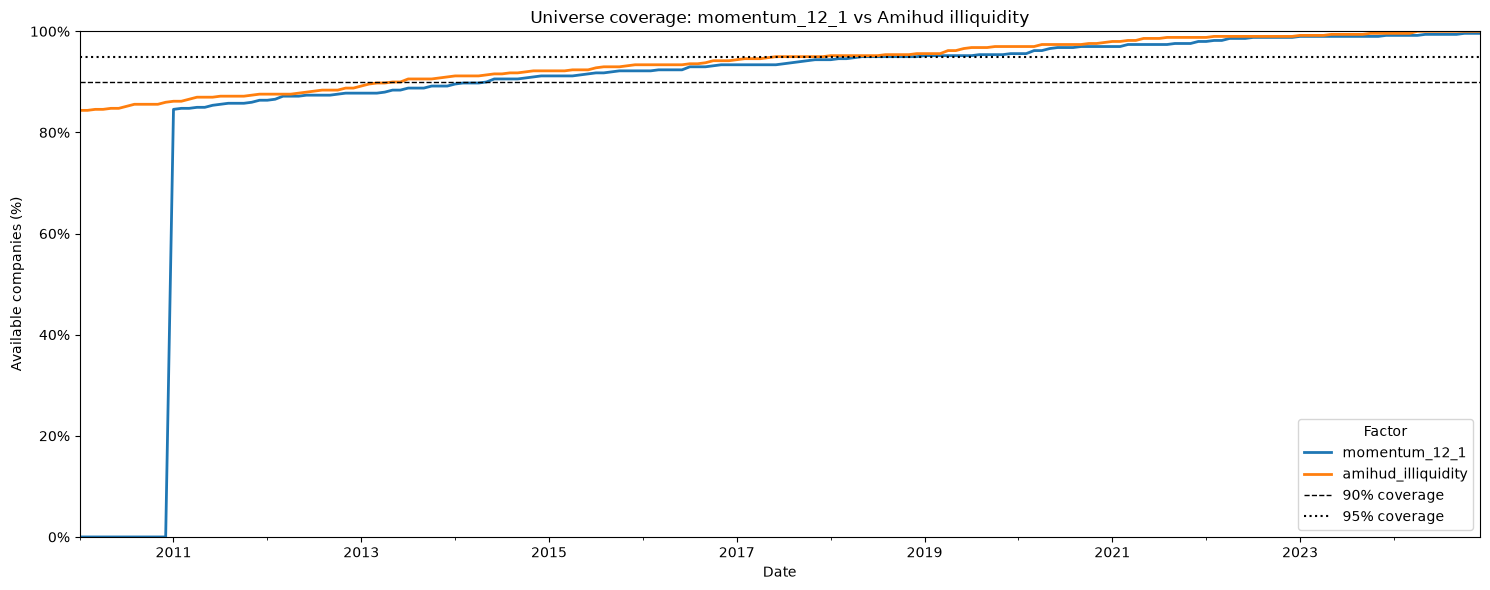

In [5]:
from src.analysis.factor_diagnostics import factor_coverage_since_first_valid

selected_factors = {
    "momentum_12_1": momentum_12_1,
    "amihud_illiquidity": amihud_illiquidity,
}

daily_factor_coverage = pd.DataFrame(
    {
        name: factor_coverage_since_first_valid(df, total_companies=499)
        for name, df in selected_factors.items()
    }
)

monthly_factor_coverage = daily_factor_coverage.resample("ME").last()

ax = monthly_factor_coverage.plot(
    figsize=(15, 6),
    linewidth=2,
    ylabel="Available companies (%)",
    title="Universe coverage: momentum_12_1 vs Amihud illiquidity",
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Factor")

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax.axhline(y=90, color="black", linestyle="--", linewidth=1, label="90% coverage")
ax.axhline(y=95, color="black", linestyle=":", linewidth=1.5, label="95% coverage")

ax.legend(title="Factor")


plt.tight_layout()
plt.show()

La diferencia en el número de warm up days entre los dos factores se ve clara ya que se muestra que prácticamente hasta 2011 el Momentum no tiene ninguna empresa disponible mientras que el Amihud Illiquidity comienza a rodar desde más del 80%. La subida vertical corresponde al día en el que la gran mayoría de empresas cumplieron los 252 días cotizados y se ve cómo a partir de ese momento los dos factores crecen en porcentaje de empresas disponibles de forma paulatina y al mismo ritmo. 

Entre el 2013 y el 2015 se llega al 90% de empresas disponibles y entre 2017 y 2019 se alcanza el 95%. 

### 2.3 Análisis de los valores NaN

Analizaremos en profundidad la cantidad y la distribución de los valores NaN dentro de las series de nuestros factores. 

In [6]:
from src.analysis.factor_diagnostics import internal_nan_count_by_ticker

print("Total NaNs after first valid by ticker:")

nans_by_factor = pd.Series(
    {
        name: internal_nan_count_by_ticker(df).sum()
        for name, df in factors.items()
    },
    name="nans_after_first_valid_by_ticker",
)

nans_by_factor

Total NaNs after first valid by ticker:


momentum_12_1             0
short_term_reversal       0
rolling_volatility        0
upside_volatility      1047
downside_volatility    1219
amihud_illiquidity     4190
Name: nans_after_first_valid_by_ticker, dtype: int64

Para los tres primeros factores (momentum, short term reversal y rolling volatility) observamos justo lo esperado, cero valores NaN internos. Es decir que, todos los NaN se acumulan al principio de la serie y no encontramos ninguna a partir del primer valor válido para cada Ticker. Realmente esto ya lo medio comprobamos al validar la data ya que nos aseguramos que no encontrábamos en el data frame de precios ningún NaN interno. 

Por otro lado sí que vamos a obervar NaNs en el upside y downside volatility y en el amihud illiquidity. Esto tiene sentido ya que la upside y downside volatility se calculan teniendo en cuenta una ventana de 252 días poniendo de restricción un mínimo de 21 días válidos. Por lo tanto, si entramos en una mala racha en el que hay muchos días seguidos con retornos negativos, la Upside volatility va a empezar a dar valores NaN. 

En el tema del Amihud Iliquidity, esos valores NaN se explican por los volúmenes nulos. La función tiene como restricción que solo se pueda dar un valor válido si de la ventana de 21 días que considera, al menos 15 son válidos, por el contrario daría NaN. 

A pesar de que podamos considerar que la cantidad de NaNs en los tres factores es suficientemente pequeña en comparación a la cantidad de valores que manejamos, realizaremos un análisis exhaustivo en ambas dimensiones: temporal y cross-sectional. 

####  2.3.1 Análisis temporal (NaNs por día y por trimestre)

En primer lugar, vamos a graficar el número de NaNs diarios (sumando los de todas las empresas) para el Upside y para el Downdside Volatility. Así podremos ver la evolución del porcentaje de NaNs en el tiempo. 

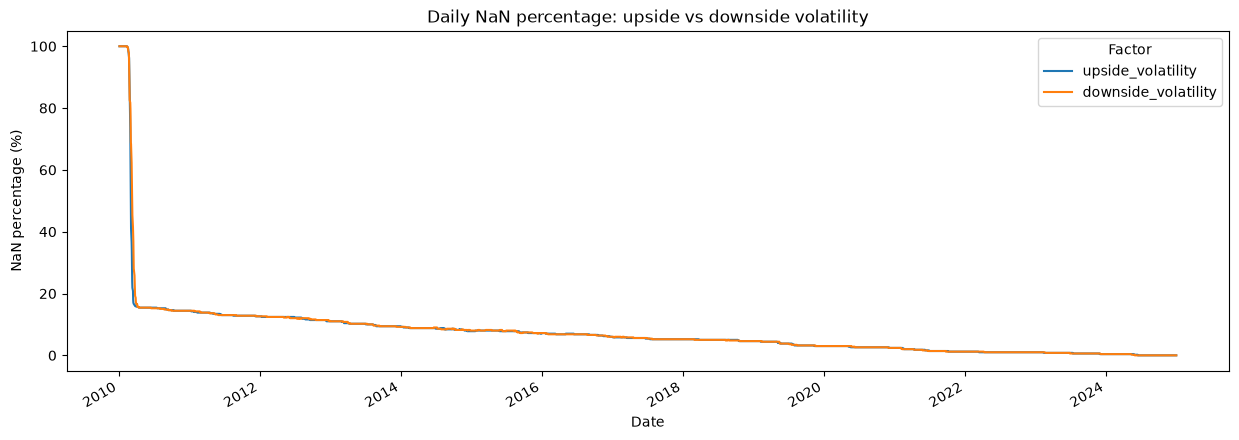

In [7]:
daily_nan_comparison_pct = pd.DataFrame(
    {
        "upside_volatility": (
            upside_volatility.isna().sum(axis=1)
            / upside_volatility.shape[1]
            * 100
        ),
        "downside_volatility": (
            downside_volatility.isna().sum(axis=1)
            / downside_volatility.shape[1]
            * 100
        ),
    }
)

ax = daily_nan_comparison_pct.plot(
    kind="line",
    figsize=(15, 5),
    linewidth=1.5,
    ylabel="NaN percentage (%)",
    title="Daily NaN percentage: upside vs downside volatility",
)

ax.legend(title="Factor")
plt.show()

Vemos exactamente lo que se esperaba: el primer mes el porcentaje de NaNs es del 100% ya que ninguna empresa, a pesar de empezar a cotizar el día uno, tiene el suficiente número de días como para que los indicadores de Upside y Donside Volatility den un valor distinto del NaN. 

Se ve justamente que al pasar esa barrera de los 29 y 28 días respectivamente, el número de NaNs de las dos volatilidades caen en picado hasta situarse por debajo del 20%. Esto se explica porque la gran mayoría de las empresas de nuestro Universo ya estaban cotizando desde el primer día que consideramso como inicio del intervalo con el que trabajamos. Después se ve cómo progresivamente el número de NaNs va cayendo hasta llegar en 2024 a menos del 10%. 

Sin embargo, lo único que podemos concluir a partir de este gráfico es que la gran mayoría de NaNs provienen del tiempo en el que las empresas no cotizaban, es decir, que la proporción de NaNs internos es bastante inferior a la de NaNs antes de cotización. Realmente para poder ver la distribución de los NaNs internos tenemos que no considerar el otro tipo. 

El siguiente gráfico agrupa por trimestres el número de NaNs presentes en cada una de las volatilidades. La diferencia es que ahora solamente se contabilizan los NaNs de las empresas que ya han tenido al menos un día de cotización distinto del NaN, así nos aseguramos de solo incluir los internos. 

<Axes: title={'center': 'Quarterly internal NaNs: upside vs downside volatility'}, xlabel='Date', ylabel='Internal NaN count'>

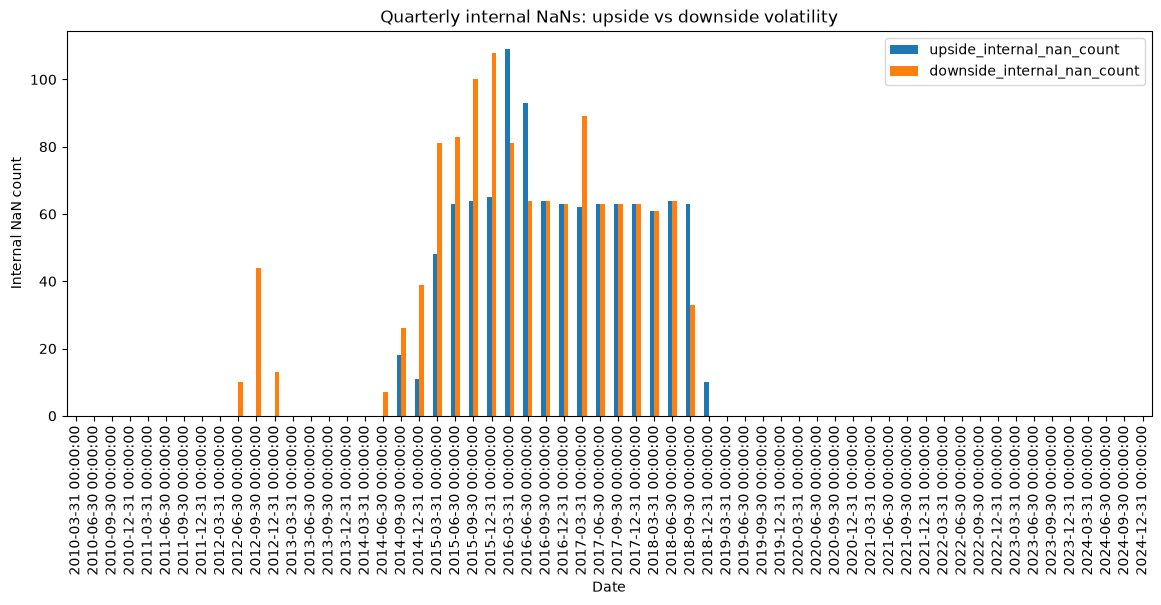

In [8]:
from src.analysis.factor_diagnostics import internal_nans_by_quarter

upside_quarterly = internal_nans_by_quarter(upside_volatility).add_prefix("upside_")
downside_quarterly = internal_nans_by_quarter(downside_volatility).add_prefix("downside_")

volatility_nan_comparison = pd.concat(
    [upside_quarterly, downside_quarterly],
    axis=1,
)

volatility_nan_comparison[
    ["upside_internal_nan_count", "downside_internal_nan_count"]
].plot(
    kind="bar",
    figsize=(14, 5),
    ylabel="Internal NaN count",
    title="Quarterly internal NaNs: upside vs downside volatility",
)

Observamos que el número de NaNs por trimestres se concentran entre el año 2014 y 2017. Después cuando analicemos la otra dimension (en vez de temporal, por empresa) obtendremos más información. 

Igualmente estos números no preocupan ya que el máximos de NaNs que llegamos a tener en un trimestre son de en torno a unos 100 para ambos factores y teniendo en cuenta que en un trimestre tenemos por factor unas 30000 observaciones (63 días por las 499 empresas), la proporción es ridícula. 


Realizaremos la misma gráfica para el último factor Amihud Illiquidity para ver la evolución temporal del número de NaNs.  

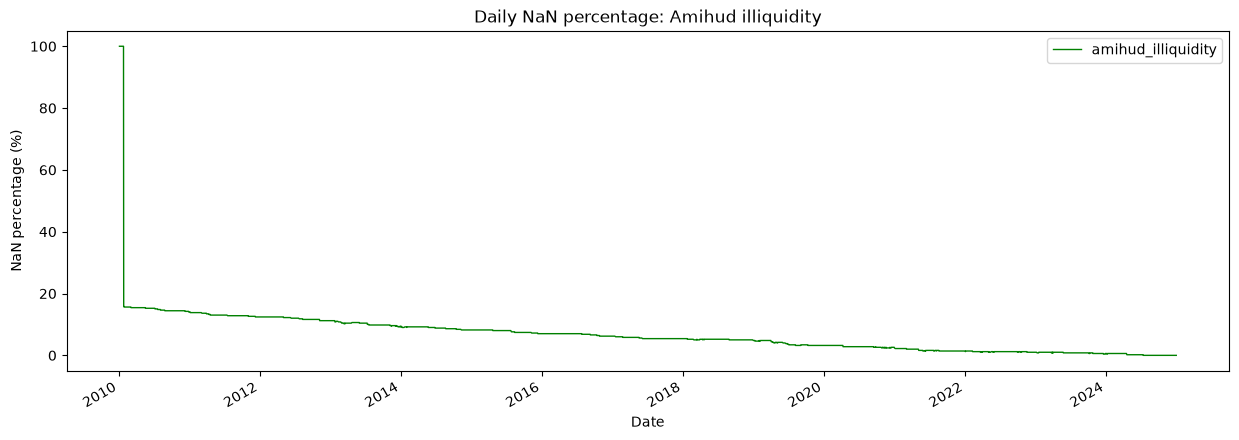

In [9]:
daily_amihud_nan_pct = (
    amihud_illiquidity.isna().sum(axis=1)
    / amihud_illiquidity.shape[1]
    * 100
)

ax = daily_amihud_nan_pct.plot(
    kind="line",
    figsize=(15, 5),
    linewidth=1,
    ylabel="NaN percentage (%)",
    title="Daily NaN percentage: Amihud illiquidity",
    color="green"
)

ax.legend(["amihud_illiquidity"])
plt.show()

Comprobamos el mismo comportamiento, el número de NaNs comienza siendo máximo hasta que se cumplen el periodo mínimo de 15 días y el número de NaNs cae drásticamente. 

#### 2.3.2 Análisis cross-sectional (NaNs por empresa)

Podemos comprobar también el número de NaNs por empresa. Lo que haremos es identificar el top 3 de empresas con mayor número de NaNs totales para cada uno de los tres factores que nos conciernen: Upside y Downside Volatility y Amihud Illiquidity (los otro tres no presentan NaNs internos). 

Los otros tres factores no presentan valores NaN internos. 

In [10]:
selected_factors = {
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

top3_internal_nans_selected = pd.concat(
    {
        factor_name: internal_nan_count_by_ticker(df).head(3)
        for factor_name, df in selected_factors.items()
    },
    names=["factor", "ticker"],
).to_frame("internal_nan_count")

top3_internal_nans_selected

internal_nan_count
factor              ticker                    
upside_volatility   AMCR                   940
                    SW                     107
                    VRSN                     0
downside_volatility AMCR                   925
                    SW                     294
                    VRSN                     0
amihud_illiquidity  SW                    2677
                    AMCR                  1513
                    VRSN                     0

Podemos darnos cuenta que los NaNs internos no están distribuidos homogéneamente entre empresas sino que se concentran, para los tres factores, en dos únicas empresas: AMCR (Amcor plc) y SW (Smurfit Westrock plc)

### 2.3 Conclusiones y decisiones de limpieza 

1. Diagnóstico e Integridad de la Serie (Filtros del Universo)

Durante el análisis de calidad de datos, se identificaron dos activos (AMCR — Amcor plc y SW — Smurfit Westrock plc) que presentaban inconsistencias graves en su registro histórico. Específicamente, se detectaron períodos prolongados de volumen de negociación nulo, tramos totalmente planos en los precios ajustados y discontinuidades anómalas en los factores de volatilidad (upside/downside volatility).

Estas anomalías obedecen a eventos corporativos (fusiones y reestructuraciones) que derivaron en la creación de nuevos tickers con datos históricos reconstruidos sintéticamente. Dado que estos tramos no reflejan un activo negociado de forma continua en el mercado, se ha decidido excluir ambas compañías del universo de inversión, evitando así introducir señales artificiales o distorsiones en el cálculo de los factores.

2. Definición del Período de Análisis Limpio (Warm-up)

El período oficial de análisis comienza a partir del cumplimiento de las primeras 252 sesiones bursátiles del dataset. Este umbral corresponde a la ventana de observación (lookback window) más exigente de los factores construidos (como el Momentum 12-1 o la Volatilidad Histórica a 252 días).

De este modo, se garantiza que la totalidad de los factores de ventana móvil estén plenamente definidos y que la cobertura transversal (cross-sectional) sea estable y homogénea desde la primera fecha efectiva del estudio, habiendo descartado por completo la fase de warm-up.

In [11]:
# decisions from the diagnostics
tickers_to_remove = ["SW", "AMCR"]
analysis_start_date = prices.index[252]

# dataset cleaning based on the diagnostics results
prices_clean = prices.loc[analysis_start_date:].drop(
    columns=tickers_to_remove, level=1, errors="ignore"
)

momentum_12_1_clean = momentum_12_1.loc[analysis_start_date:].drop(columns=tickers_to_remove)

short_term_reversal_clean = short_term_reversal.loc[analysis_start_date:].drop(columns=tickers_to_remove)

rolling_volatility_clean = rolling_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

upside_volatility_clean = upside_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

downside_volatility_clean = downside_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

amihud_illiquidity_clean = amihud_illiquidity.loc[analysis_start_date:].drop(columns=tickers_to_remove)

## 3. Análisis de Distribución (Univariado)

### Tabla consolidada de estadísticos globales

In [12]:
factors_clean = {
    "momentum_12_1": momentum_12_1_clean,
    "short_term_reversal": short_term_reversal_clean,
    "rolling_volatility": rolling_volatility_clean,
    "upside_volatility": upside_volatility_clean,
    "downside_volatility": downside_volatility_clean,
    "amihud_illiquidity": amihud_illiquidity_clean,
}

summary = []

for name, df in factors_clean.items():

    values = df.stack().dropna()

    summary.append({
        "Factor": name,
        "Mean": values.mean(),
        "Std": values.std(),
        "Min": values.min(),
        "P25": values.quantile(0.25),
        "P50": values.median(),
        "P75": values.quantile(0.75),
        "Max": values.max(),
        "Skewness": values.skew(),
        "Kurtosis": values.kurt()
    })

summary_table = (
    pd.DataFrame(summary)
      .set_index("Factor")
)

summary_table.map(lambda x: f"{x:.4g}")

,Mean,Std,Min,P25,P50,P75,Max,Skewness,Kurtosis
Factor,,,,,,,,,
momentum_12_1,0.1724,0.3413,-0.98,-0.01466,0.1392,0.3067,11.51,3.918,54.3
short_term_reversal,0.01497,0.08754,-0.8717,-0.03093,0.01473,0.05894,2.185,0.5552,11.6
rolling_volatility,0.01827,0.008023,0.003277,0.01283,0.01627,0.02152,0.1138,2.087,8.756
upside_volatility,0.0123,0.006103,0.002316,0.008199,0.01069,0.0147,0.0928,2.211,9.343
downside_volatility,0.01326,0.006899,0.002321,0.008851,0.01144,0.0155,0.09549,2.659,13.84
amihud_illiquidity,3.144e-10,4.308e-09,3.571e-13,4.146e-11,8.516e-11,1.697e-10,7.271e-07,86.1,1.047e+04


El análisis de los estadísticos univariados consolidados sobre la muestra limpia revela heterogeneidades severas en la escala, asimetría y densidad de las colas de los factores, aportando una prueba empírica concluyente para el posterior preprocesamiento de datos. Destaca en primer lugar una acusada disparidad en las magnitudes físicas del panel, donde el momentum a doce meses se expresa en retornos acumulados anuales con una media del 17.24%, las volatilidades se sitúan en rangos diarios medios del 1.23% al 1.82%, y la iliquidez de Amihud se mueve en micro-escalas con una mediana de $8.516 \times 10^{-11}$. Esta dispersión de órdenes de magnitud confirma que las variables resultan incommensurables entre sí sin la aplicación previa de una estandarización transversal.

El hallazgo más crítico del diagnóstico reside en la iliquidez de Amihud, cuya asimetría de 86.1 y curtosis de 10,470 —si bien se han reducido sustancialmente tras el filtrado de calidad inicial— continúan reflejando un comportamiento extremadamente sesgado a la derecha. Este fenómeno es inherente a jornadas de volumen de negociación residual en ciertos activos, donde divisiones por un denominador cercano a cero generan picos de escala impredecibles que hacen imprescindible una transformación logarítmica o un filtrado riguroso de valores atípicos. Por su parte, el momentum_12_1 exhibe un marcado sesgo positivo con una curtosis de 54.3 y un valor máximo del 1,151%, representativo de activos con comportamientos parabólicos en el periodo analizado, frente a un límite inferior de -98% que respeta de forma coherente el suelo teórico del -100%.

En lo relativo a los factores de volatilidad, la comparación entre componentes direccionales confirma la presencia del efecto apalancamiento (leverage effect), observándose que la downside volatility presenta una media ligeramente superior (1.326%) respecto a la upside volatility (1.230%), acompañada de una mayor curtosis (13.84 frente a 9.34) y asimetría (2.659 frente a 2.211), lo que demuestra que las perturbaciones negativas en el mercado generan colas más anchas e intensas. En el extremo opuesto, el factor de reversión a corto plazo se consolida como la métrica más simétrica y estable del panel, con una media cercana a cero y una curtosis de 11.60. En conjunto, la persistencia de estos valores extremos y la incompatibilidad de escalas exigen de forma obligatoria la estandarización transversal por puntuación Z y la aplicación de un proceso de winsorizing en cada sección cruzada antes de acometer cualquier fase de modelado.

### 3.1 Análisis de la Distribución de Factores (Histogramas)

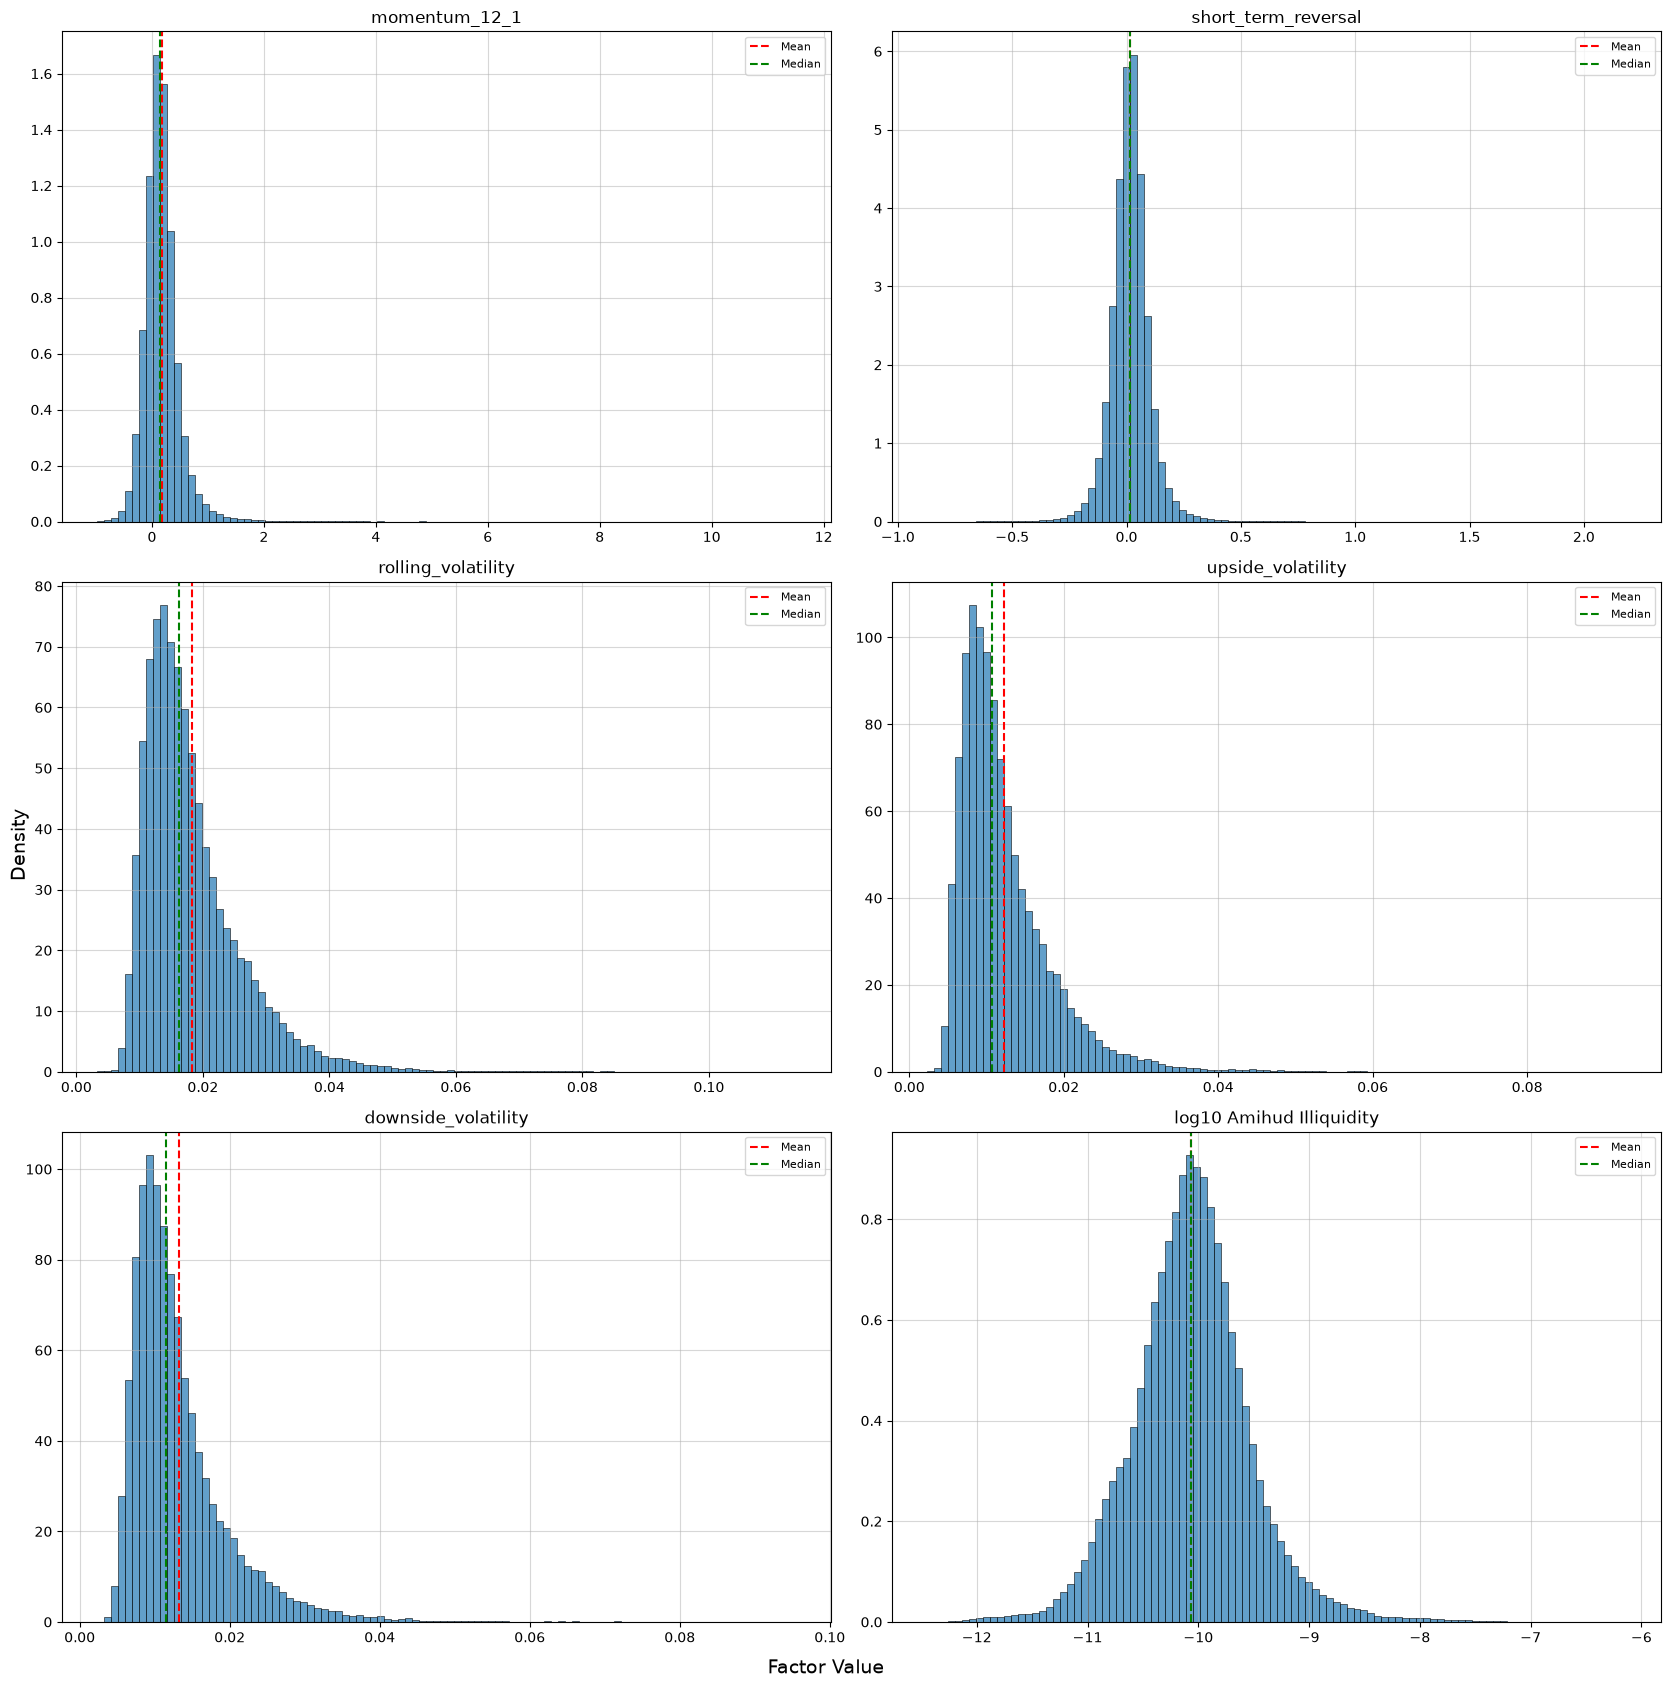

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(17, 17))
axes = axes.flatten()

for ax, (name, df) in zip(axes, factors_clean.items()):

    values = df.stack().dropna()

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        values = np.log10(values[values > 0])   # avoid issues with zeros
        title = "log10 Amihud Illiquidity"
        xlabel = "log10(Amihud)"
    else:
        title = name
        xlabel = "Factor value"

    sns.histplot(
    values,
    bins=100,
    kde=False,
    stat="density",
    edgecolor="black",
    alpha=0.7,
    ax=ax
)

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.5)
    ax.set_ylabel("")
    ax.axvline(values.mean(), color="red", linestyle="--",
           linewidth=1.5, label="Mean")
    ax.axvline(np.median(values), color="green", linestyle="--",
           linewidth=1.5, label="Median")
    ax.legend(fontsize=8)

fig.supxlabel("Factor Value", fontsize=14)
fig.supylabel("Density", fontsize=14)

plt.tight_layout()
plt.show()

El análisis visual mediante histogramas confirma los patrones observados en los estadísticos descriptivos, mostrando distribuciones alejadas de la normalidad teórica y revelando los sesgos característicos de cada métrica financiera. Se prescinde de las curvas de estimación de densidad por kernel (KDE) debido a que, al trabajar con una muestra de gran tamaño y fijar un número elevado de bins en los histogramas, la resolución discreta aproxima de forma casi exacta la función de densidad subyacente.

En primer lugar, la aplicación de la transformación **$\log_{10}$ al factor `amihud_illiquidity**` permite resolver la compresión extrema que sufría en su escala original. Al trasponer los datos a escala logarítmica, la distribución abandona la "L" o pared vertical original para desplegar una campana continua y bien definida, centrada en torno a su mediana (alrededor de $-10.07$ en escala base 10). No obstante, el gráfico sigue mostrando una asimetría positiva moderada y una cola derecha extendida hacia valores menos negativos ($\log_{10} \approx -6.14$), correspondiente a aquellas jornadas o activos con niveles de iliquidez atípicamente elevados. Esta visualización confirma que la transformación logarítmica es completamente acertada y necesaria para estabilizar la varianza del factor antes de su procesamiento.

Por su parte, los tres factores de volatilidad (**`rolling_volatility`**, **`upside_volatility`** y **`downside_volatility`**) exhiben distribuciones asimétricas positivas bien definidas. Al estar delimitadas inferiormente por el cero, las masas de probabilidad crecen rápidamente hasta alcanzar sus picos alrededor del 1.0%–1.6% diario, para posteriormente decaer suavemente hacia la derecha. Destaca de forma muy clara la diferencia visual entre las dos volatilidades direccionales: la **`downside_volatility`** dibuja una cola derecha significativamente más larga, gruesa y distante del cuerpo central que la **`upside_volatility`**, plasmando gráficamente el pico de dispersión que sufren los activos durante las jornadas de pánico bursátil.

En el caso del **`momentum_12_1`**, el gráfico muestra un cuerpo central desplazado ligeramente hacia la derecha del cero, con un suelo rígido en el $-0.98$ que frena abruptamente la cola izquierda. Resulta especialmente interesante comparar la estructura del *momentum* con la de las volatilidades o la del propio *Amihud*: si bien alcanza un valor máximo absoluto muy elevado ($11.51$), el gráfico no exhibe una cola derecha estirada de forma uniforme como en las volatilidades, ni una distancia tan acusada entre su media ($0.1724$) y su mediana ($0.1392$). Esto obedece a que su elevadísima curtosis ($54.3$) concentra a la abrumadora mayoría de los datos en torno a la moda central, haciendo que los valores extremos actúen como observaciones atípicas aisladas (*outliers* lejanos) más que como una masa continua de cola ancha.

Finalmente, el factor **`short_term_reversal`** es el único del conjunto que muestra una forma visual cercana a una campana simétrica centrada prácticamente en el cero. Sin embargo, a diferencia de una distribución Normal estándar, el histograma revela un pico central extremadamente agudo y alto —consecuencia directa de su curtosis de 11.60— acompañado de caídas muy rápidas hacia los lados, lo que constata una gran concentración de retornos diarios neutros interrumpida únicamente por shocks puntuales en las colas.

### 3.2 Análisis de las gráficas QQ plots por factores

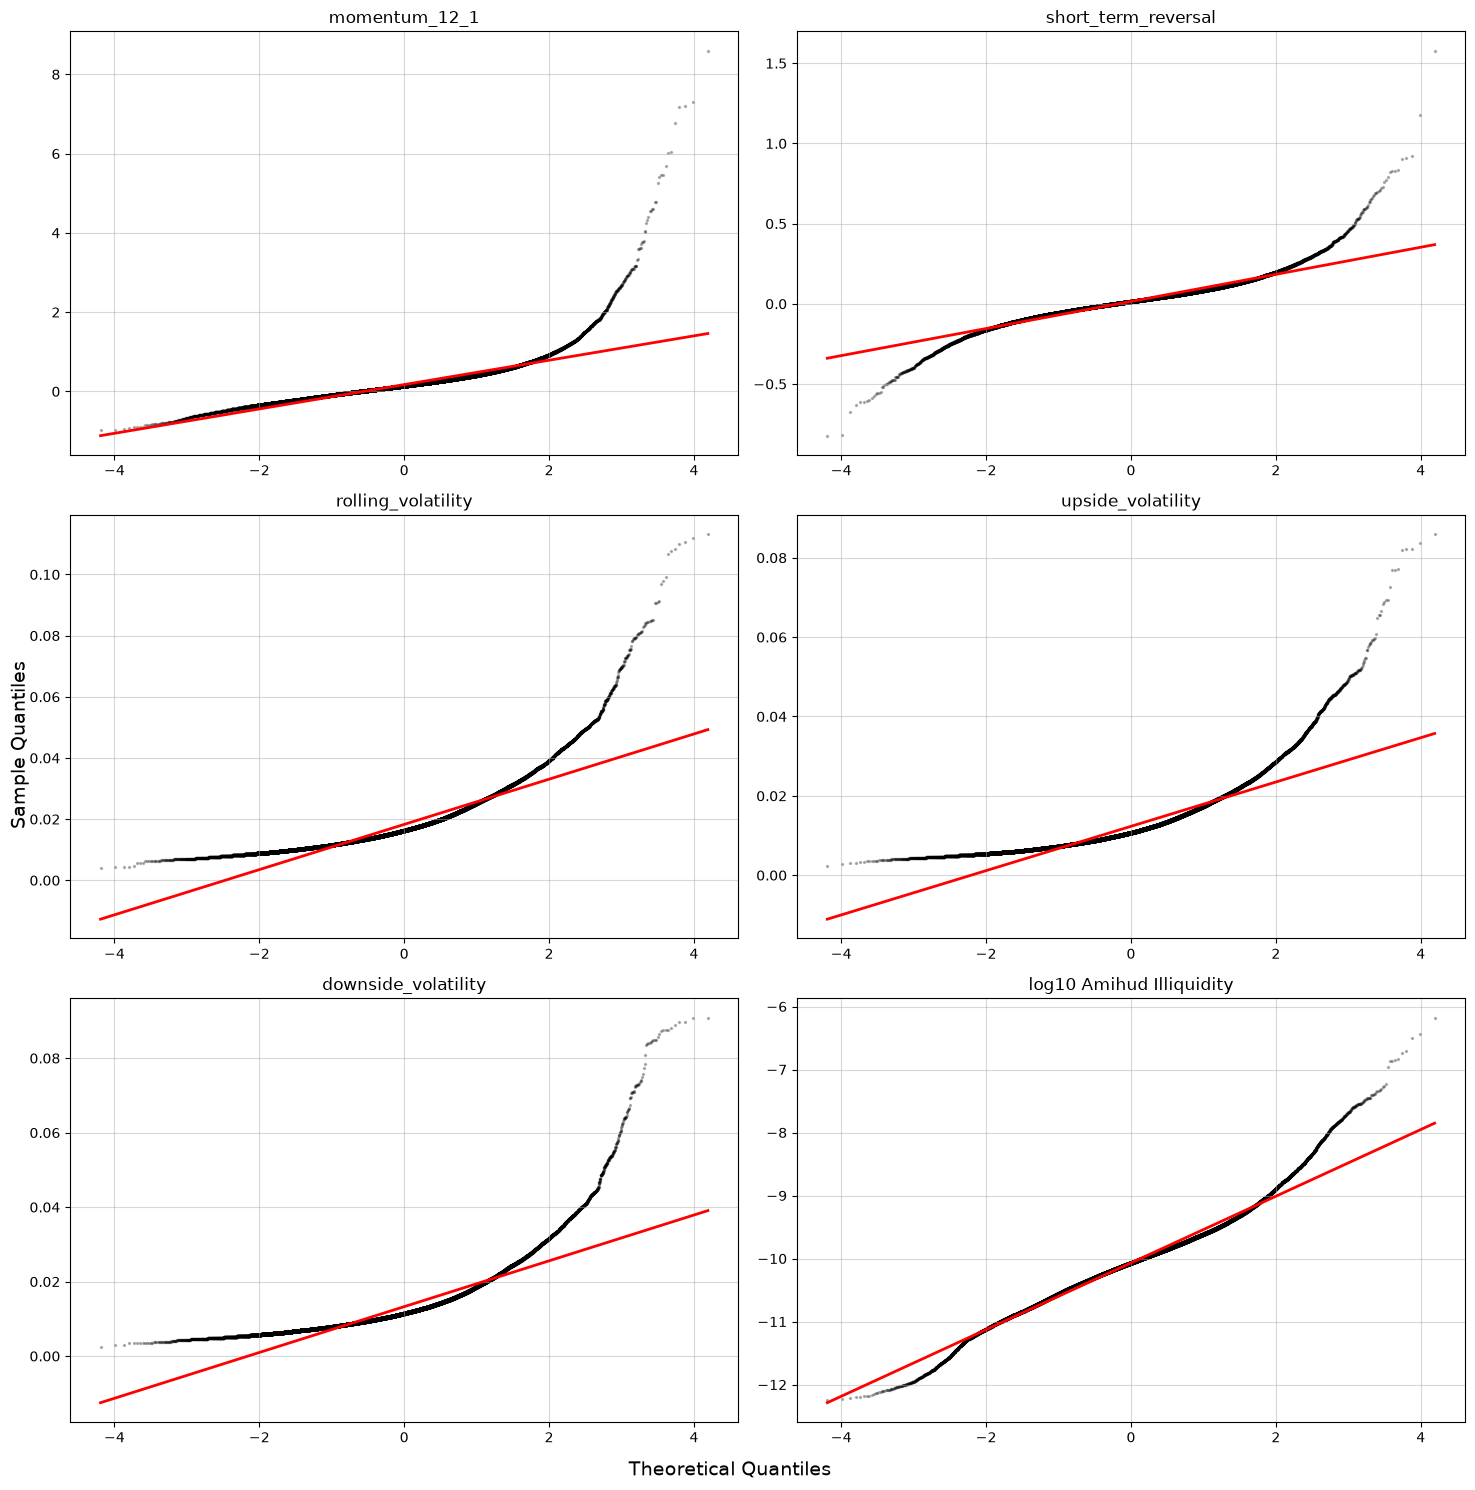

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for ax, (name, df) in zip(axes, factors_clean.items()):

    values = df.stack().dropna()

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        values = np.log10(values[values > 0])
        title = "log10 Amihud Illiquidity"
    else:
        title = name

    # Sample 50,000 observations for visualization
    if len(values) > 50000:
        values = values.sample(50000, random_state=42)

    # Compute QQ plot data
    (osm, osr), (slope, intercept, r) = stats.probplot(values, dist="norm")

    # Scatter points
    ax.scatter(
        osm,
        osr,
        s=8,
        color="black",
        alpha=0.25,
        marker="."
    )

    # Reference line
    ax.plot(
        osm,
        slope * osm + intercept,
        color="red",
        linewidth=2
    )

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.5)

fig.supxlabel("Theoretical Quantiles", fontsize=14)
fig.supylabel("Sample Quantiles", fontsize=14)

plt.tight_layout()
plt.show()

El análisis de los gráficos Q-Q confirma la presencia de colas pesadas y el incumplimiento severo de la normalidad gaussiana en todos los factores. En **`log10_amihud`**, aunque la transformación logarítmica logra acoplar el cuerpo central a la recta teórica, ambas colas terminan divergiendo de la diagonal, mostrando una desviación sensiblemente más acusada en el extremo derecho producto de picos persistentes de iliquidez. En el caso del **`momentum_12_1`**, la cola izquierda se adhiere con fidelidad a la Normal —frenada por el límite económico insuperable del $-100\%$—, mientras que el extremo derecho se dispara verticalmente debido a la presencia de retornos acumulados excepcionalmente elevados.

Por su parte, el factor **`short_term_reversal`** dibuja la clásica geometría en "S" de las distribuciones leptocúrticas: la masa central se mantiene totalmente pegada a la referencia teórica, pero ambas colas se separan de forma simétrica confirmando que los shocks diarios de mercado sufren eventos extremos con mayor frecuencia de la prevista. Finalmente, las tres volatilidades exhiben un perfil parabólico cóncavo hacia arriba derivado de su acotación en cero y su asimetría positiva. En ellas, la cola derecha de la **`downside_volatility`** se eleva con mayor pendiente y densidad que la de la **`upside_volatility`**, dejando evidencia gráfica del mayor riesgo de cola asociado a las dinámicas de caídas en el mercado.

### 3.3 Análisis de Valores Atípicos (Outliers)

El diagnóstico de valores atípicos (outliers) se aborda mediante un enfoque no paramétrico basado en el rango intercuartílico, metodología idónea para distribuciones que incumplen el supuesto de normalidad y exhiben colas pesadas. Los resultados confirman que la presencia de registros extremos no responde a errores en la toma o cálculo de los datos, sino a dinámicas genuinas del mercado financiero —como shocks macroeconómicos, episodios puntuales de iliquidez o fuertes movimientos de precios—, cuya caracterización resulta fundamental para comprender el comportamiento de las colas de cada factor antes de cualquier análisis posterior.

Los valores atípicos se identificaron mediante la regla de Tukey (1.5 × IQR). Para cada factor se calcularon el primer (Q1) y el tercer cuartil (Q3), obteniendo el rango intercuartílico IQR=Q3−Q1. Se consideraron valores atípicos aquellas observaciones situadas por debajo de Q1−1.5×IQR o por encima de Q3+1.5×IQR.

In [15]:
outliers_summary = []

for name, df in factors_clean.items():

    values = df.stack().dropna()

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        values = np.log10(values[values > 0])
        factor_name = "log10 Amihud Illiquidity"
    else:
        factor_name = name

    # Quartiles
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    # Tukey bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Outliers
    outliers = ((values < lower_bound) | (values > upper_bound)).sum()
    pct_outliers = 100 * outliers / len(values)

    outliers_summary.append({
        "Factor": factor_name,
        "Outliers (%)": pct_outliers
    })

outlier_table = (
    pd.DataFrame(outliers_summary)
      .set_index("Factor")
      .round(2)
)

display(outlier_table)

,Outliers (%)
Factor,
momentum_12_1,4.17
short_term_reversal,4.43
rolling_volatility,4.16
upside_volatility,4.36
downside_volatility,5.60
log10 Amihud Illiquidity,3.23


El diagnóstico cuantitativo revela que la proporción de valores atípicos oscila entre el 3.23% y el 5.60% del total de observaciones, cifras completamente alineadas con los estándares empíricos de la renta variable. 

Destaca especialmente el contraste entre las volatilidades direccionales: la downside_volatility registra la mayor concentración de outliers del panel (5.60%), superando de forma clara a la upside_volatility (4.36%), lo que corrobora cuantitativamente la asimetría del riesgo de cola y el impacto de los episodios de pánico en el mercado. 

Por su parte, la moderada proporción de registros atípicos en log10_amihud (3.23%) valida la efectividad de la transformación logarítmica para estabilizar la varianza, mientras que los valores atípicos de momentum_12_1 (4.17%) y short_term_reversal (4.43%) plasman la frecuencia con la que se producen fuertes dinámicas de revalorización y reacciones diarias de reajuste dentro del S&P 500.

### 3.4 Conclusiones

La presencia estructural de colas pesadas y observaciones atípicas en todo el panel justifica plenamente la necesidad de aplicar técnicas de acondicionamiento en el siguiente módulo (winsorización transversal y estandarización) para evitar la distorsión de los modelos cuantitativos posteriores.

In [16]:
# Diagnostic Summary Table (EDA Phase)
diagnostic_data = {
    'Factor': [
        'Momentum (12-1)',
        'Short-Term Reversal',
        'Rolling Volatility',
        'Upside Volatility',
        'Downside Volatility',
        'log10 Amihud Illiquidity'
    ],
    'Tail Weight (Kurtosis)': [
        'Very High',
        'High',
        'High',
        'High',
        'Very High',
        'Moderate (Post-log)'
    ],
    'Primary Skewness': [
        'Positive',
        'Neutral-Slight',
        'Positive',
        'Positive',
        'Positive',
        'Positive'
    ],
    'Outlier Impact': [
        'High',
        'Moderate',
        'Moderate-High',
        'Moderate',
        'High',
        'Controlled'
    ]
}

df_summary = (
    pd.DataFrame(diagnostic_data)
      .set_index("Factor")
)
    
display(df_summary)

,Tail Weight (Kurtosis),Primary Skewness,Outlier Impact
Factor,,,
Momentum (12-1),Very High,Positive,High
Short-Term Reversal,High,Neutral-Slight,Moderate
Rolling Volatility,High,Positive,Moderate-High
Upside Volatility,High,Positive,Moderate
Downside Volatility,Very High,Positive,High
log10 Amihud Illiquidity,Moderate (Post-log),Positive,Controlled


## 4. Comportamiento Temporal y Estabilidad Cross-Sectional

Evaluar la estabilidad temporal de los factores y verificar que mantienen una variabilidad suficiente en la sección transversal a lo largo del periodo de estudio. Un factor cuya distribución colapsa o pierde dispersión deja de ser útil para discriminar entre activos.

### 4.1 Tendencia Central y Asimetría (Media vs. Mediana)

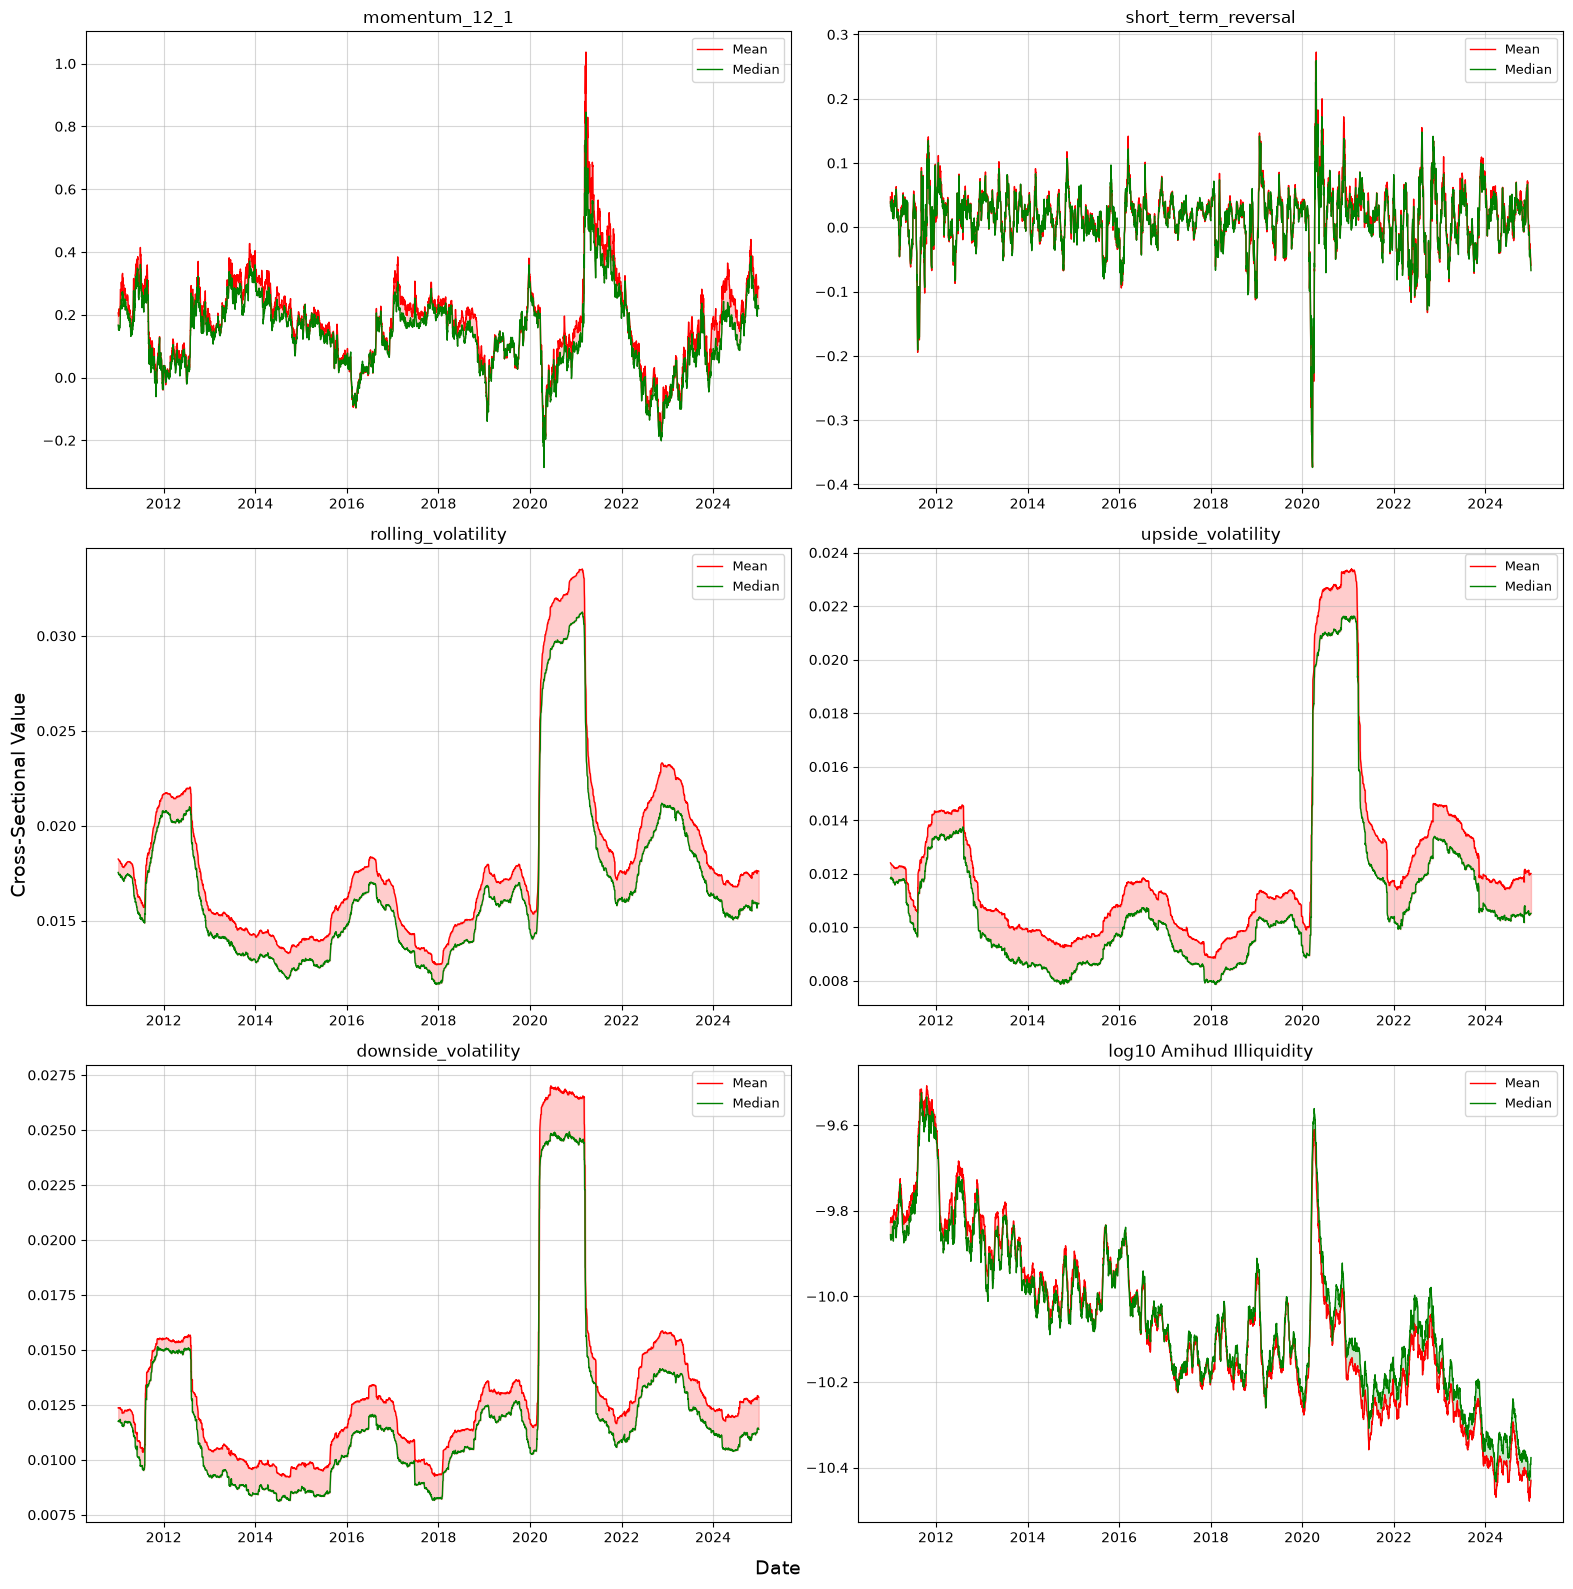

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, (name, df) in zip(axes, factors_clean.items()):

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        df_plot = np.log10(df.where(df > 0))
        title = "log10 Amihud Illiquidity"
    else:
        df_plot = df
        title = name

    # daily mean and median calculations
    daily_mean = df_plot.mean(axis=1)
    daily_median = df_plot.median(axis=1)

    ax.plot(
        daily_mean.index,
        daily_mean,
        label="Mean",
        linewidth=1,
        color="red"
    )

    ax.plot(
        daily_median.index,
        daily_median,
        label="Median",
        linewidth=1,
        color="green"
    )

    ax.fill_between(
    daily_mean.index,
    daily_mean,
    daily_median,
    where=(daily_mean >= daily_median),
    color="red",
    alpha=0.20,
    interpolate=True,
    )

    ax.fill_between(
        daily_mean.index,
        daily_mean,
        daily_median,
        where=(daily_mean < daily_median),
        color="green",
        alpha=0.20,
        interpolate=True,
    )

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.5)
    ax.legend(fontsize=9)

fig.supxlabel("Date", fontsize=14)
fig.supylabel("Cross-Sectional Value", fontsize=14)

plt.tight_layout()
plt.show()

El análisis temporal de la tendencia central revela marcadas diferencias en la estructura de los factores según su naturaleza financiera. En los factores de retorno, Short-Term Reversal presenta una superposición casi idéntica entre la media y la mediana a lo largo de todo el periodo, comportándose como un ruido blanco centrado en cero que solo amplifica sus oscilaciones de forma drástica durante periodos de extremo estrés de mercado, como el crash de 2020. 

Por su parte, Momentum mantiene de forma constante su media ligeramente por encima de la mediana; aunque ambas evolucionan de forma muy volátil, esta brecha persistente confirma una asimetría positiva estructural impulsada por una minoría de activos con rendimientos parabólicos en la cola derecha. Esta concentración es aún más evidente en los factores de volatilidad, donde la media cotiza sistemáticamente y por un amplio margen por encima de la mediana, demostrando que el riesgo de mercado no es homogéneo sino que se concentra permanentemente en un pequeño grupo de valores muy volátiles. 

Por último, la iliquidez de Amihud muestra una superposición estrecha entre ambas métricas pero acompañada de una clara tendencia descendente a lo largo de los últimos años, lo que refleja una paulatina inyección de liquidez y un menor impacto del volumen en el panel general del mercado.

### 4.2 Dispersión y Capacidad Discriminatoria ($\text{IQR}_t$ vs. $\sigma_t$)

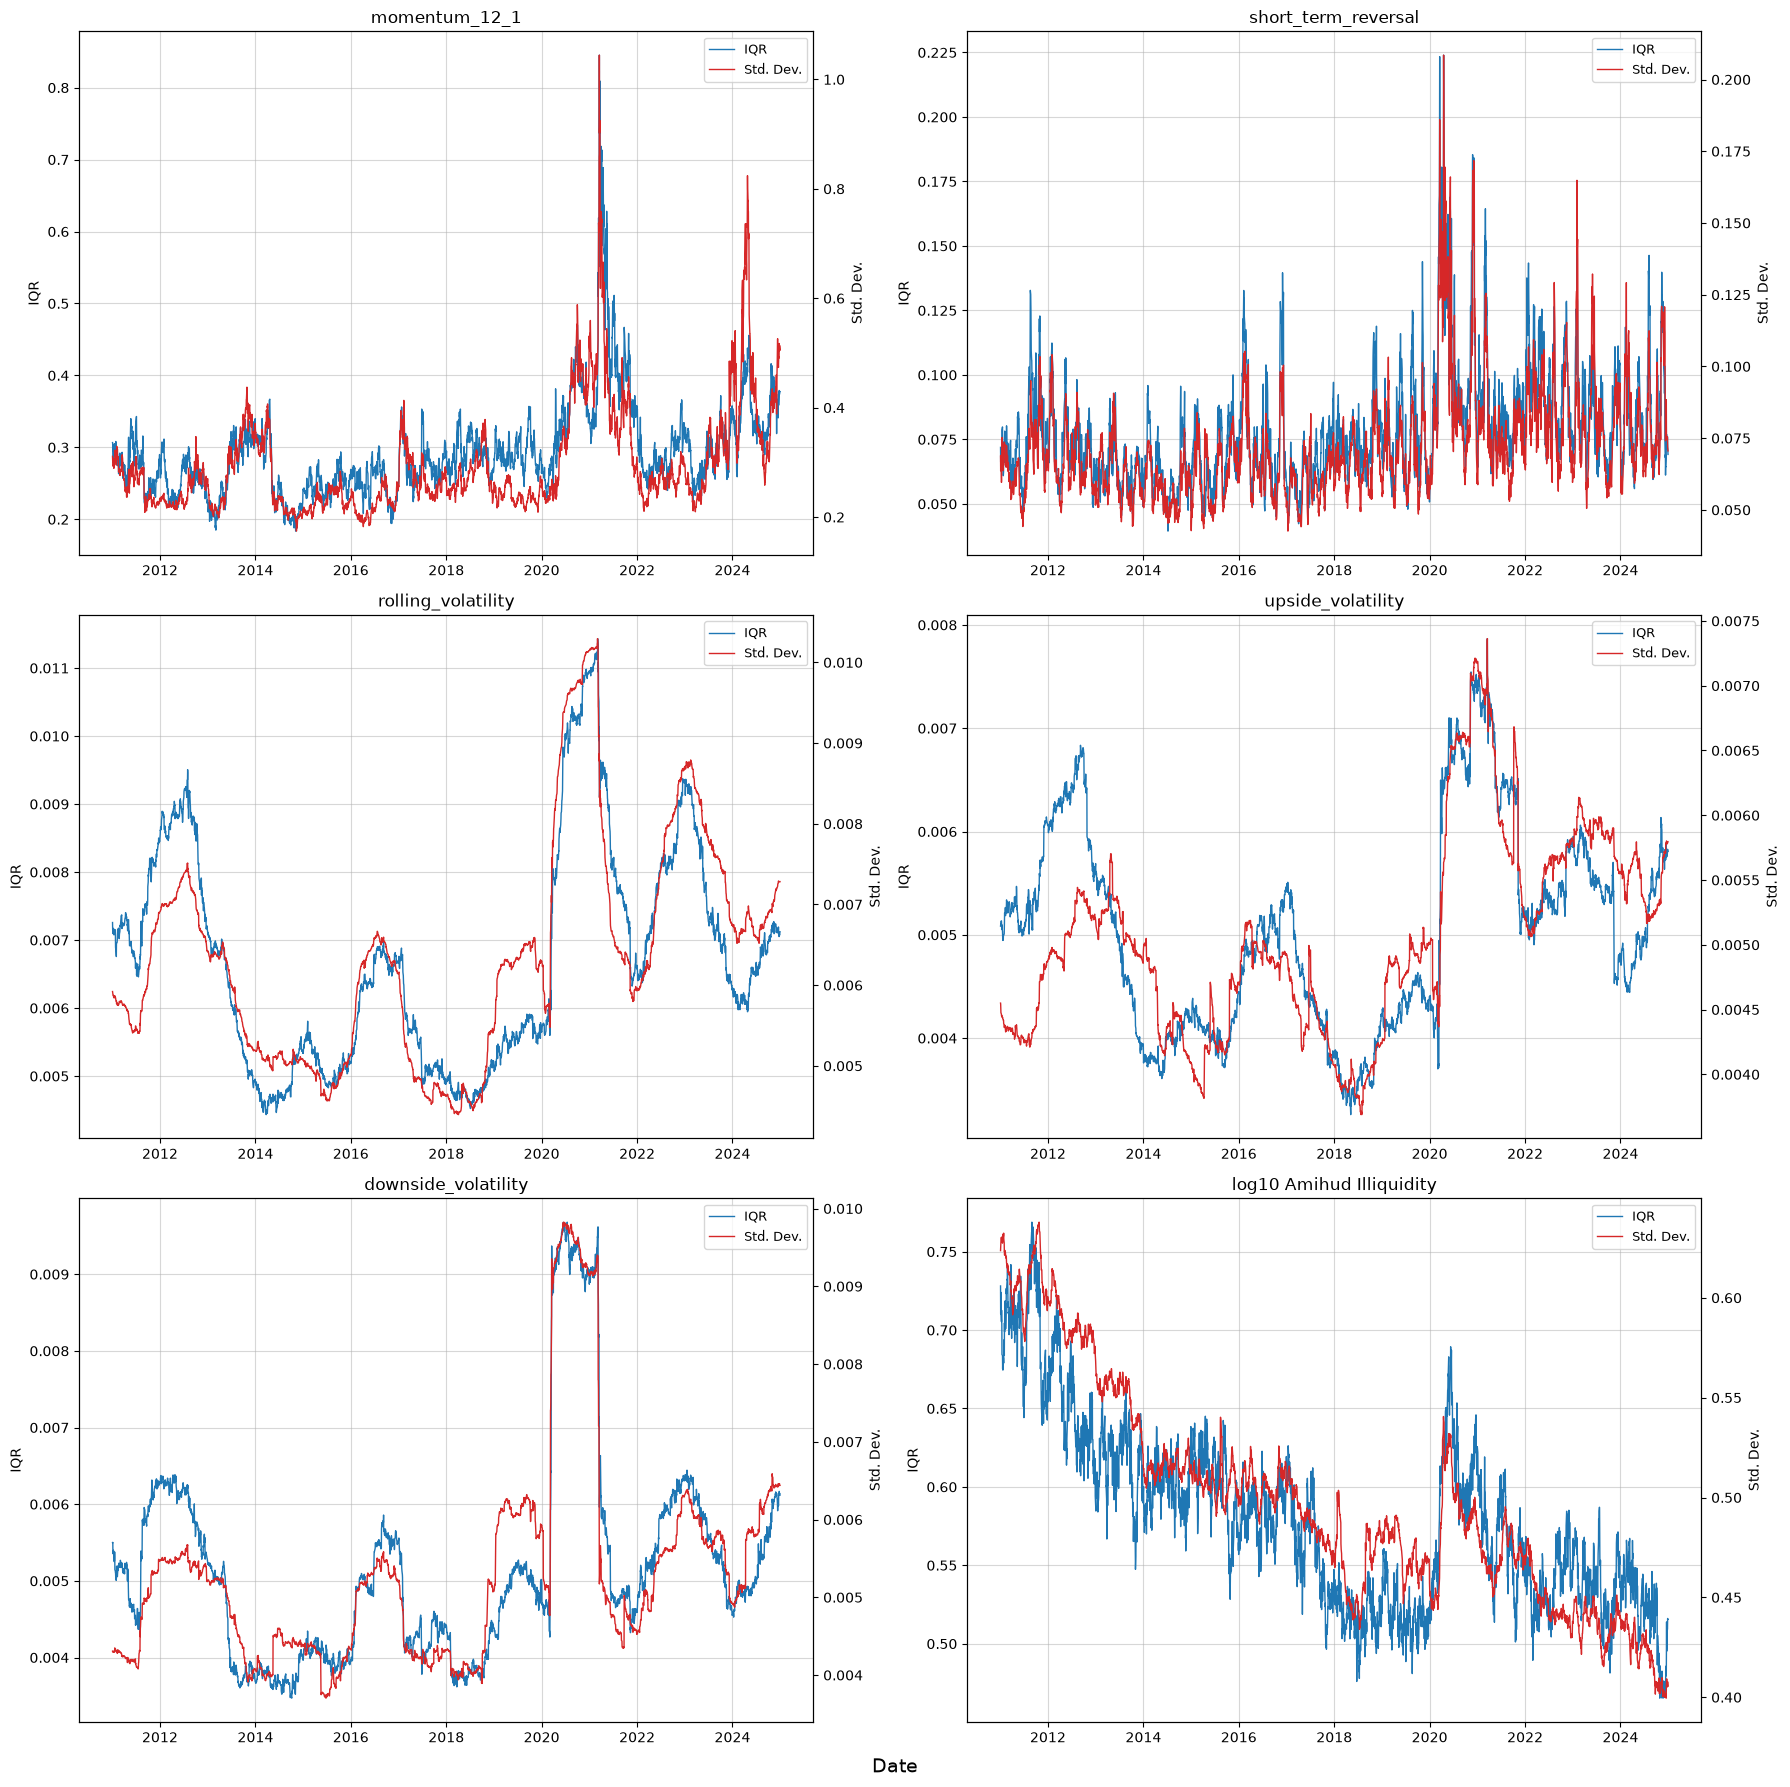

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, (name, df) in zip(axes, factors_clean.items()):

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        df_plot = np.log10(df.where(df > 0))
        title = "log10 Amihud Illiquidity"
    else:
        df_plot = df
        title = name

    # Daily cross-sectional statistics

    daily_q25 = df_plot.quantile(0.25, axis=1)
    daily_q75 = df_plot.quantile(0.75, axis=1)
    daily_iqr = daily_q75 - daily_q25

    daily_std = df_plot.std(axis=1)

    # ---------- Left axis : IQR ----------

    ax.plot(
        daily_iqr.index,
        daily_iqr,
        color="tab:blue",
        linewidth=1,
        label="IQR"
    )

    ax.set_ylabel("IQR", color="black")
    ax.tick_params(axis="y", labelcolor="black")

    # ---------- Right axis : Standard Deviation ----------

    ax2 = ax.twinx()

    ax2.plot(
        daily_std.index,
        daily_std,
        color="tab:red",
        linewidth=1,
        label="Std. Dev."
    )

    ax2.set_ylabel("Std. Dev.", color="black")
    ax2.tick_params(axis="y", labelcolor="black")

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.5)

    # Combined legend
    lines = ax.get_lines() + ax2.get_lines()
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, fontsize=9)

fig.supxlabel("Date", fontsize=14)

plt.tight_layout()
plt.show()

El análisis de la dispersión transversal confirma que todos los factores mantienen capacidad discriminatoria a lo largo de todo el horizonte temporal, al no colapsar la línea del $\text{IQR}_t$ a cero en ningún momento. Sin embargo, la comparación de sus dinámicas temporales revela comportamientos muy diversos ante shocks de mercado. 

En *Momentum*, ambas métricas se mantienen relativamente estables a lo largo del tiempo, pero durante los episodios de volatilidad extrema de 2020 y 2024, la Desviación Estándar ($\sigma_t$) registra repuntes sensiblemente más acusados que el $\text{IQR}_t$, lo que denota que estos picos de dispersión estuvieron fuertemente impulsados por *outliers* en las colas de la distribución. Por otro lado, *Short-Term Reversal* presenta una elevada inestabilidad temporal en ambas métricas, destacando que en prácticamente todas las fases de expansión de dispersión el $\text{IQR}_t$ reacciona con subidas más pronunciadas que la desviación estándar.

Por su parte, los factores de volatilidad muestran un comportamiento síncrono donde ambas métricas suben y bajan a la par, alternándose cuál de las dos experimenta variaciones de mayor magnitud según el periodo. Finalmente, en el factor de iliquidez *Amihud*, el $\text{IQR}_t$ exhibe una volatilidad temporal mucho más acentuada que la Desviación Estándar, reaccionando con subidas considerablemente más agresivas en los repuntes de iliquidez y con caídas más profundas en las fases de calma, lo que refleja una mayor sensibilidad del 50% central del panel frente a la dispersión global del factor.

### 4.3 Conclusiones 

Se confirma la validez de los factores al comprobar que mantienen una dispersión transversal viva ($\text{IQR}_t > 0$) en cualquier entorno macroeconómico, garantizando que nunca pierden su capacidad para ordenar la cartera. Sin embargo, se observa que en ciertas fases del ciclo el $\text{IQR}_t$ sufre caídas notables; aunque el factor siga funcionando técnicamente, en esos periodos de baja dispersión su poder discriminatorio se reduce, estrechando las diferencias reales entre activos.

## 5. Persistencia y Memoria Temporal

### 5.1 Autocorrelación de primer orden por factor

In [19]:
autocorr_summary = []

for name, df in factors_clean.items():

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        df_plot = np.log10(df.where(df > 0))
        factor_name = "log10 Amihud Illiquidity"
    else:
        df_plot = df
        factor_name = name

    # lag1 autocorrelation for each ticker
    autocorr = df_plot.apply(lambda x: x.dropna().autocorr(lag=1), axis=0)

    autocorr = autocorr.dropna()

    mean_ac = autocorr.mean()
    median_ac = autocorr.median()
    iqr_ac = autocorr.quantile(0.75) - autocorr.quantile(0.25)

    autocorr_summary.append({
        "Factor": factor_name,
        "Mean": mean_ac,
        "Median": median_ac,
        "IQR": iqr_ac
    })

autocorr_table = (
    pd.DataFrame(autocorr_summary)
      .set_index("Factor")
)

display(autocorr_table.map(lambda x: f"{x:.4g}"))

,Mean,Median,IQR
Factor,,,
momentum_12_1,0.9914,0.992,0.003382
short_term_reversal,0.9435,0.9436,0.008198
rolling_volatility,0.9991,0.9995,0.0004014
upside_volatility,0.9984,0.9988,0.0009357
downside_volatility,0.9981,0.9986,0.001103
log10 Amihud Illiquidity,0.9945,0.995,0.004431


El análisis de la autocorrelación a nivel de activo confirma una elevada memoria temporal en todos los factores, con medianas del universo superiores a $0.94$. Valores tan cercanos a $1.00$ en la volatilidad, momentum e iliquidez son naturales y esperados por construcción matemática: al emplear ventanas móviles de cálculo, el dato en $t$ y $t+1$ comparte casi toda su información histórica, garantizando transiciones suaves. Además, el $\text{IQR}$ tan estrecho en todos los casos confirma que esta persistencia es un rasgo homogéneo en todo el universo de activos.

La única excepción relevante es Short-Term Reversal, cuya autocorrelación cae a $0.9436$ y presenta el mayor $\text{IQR}$ ($0.0082$). Al basarse en ventanas ultra cortas, reacciona más rápido a los shocks de precio, anticipando una menor memoria temporal y una rotación superior a horizontes más largos.

### 5.2 Correlación del Ranking (Cross-Sectional)

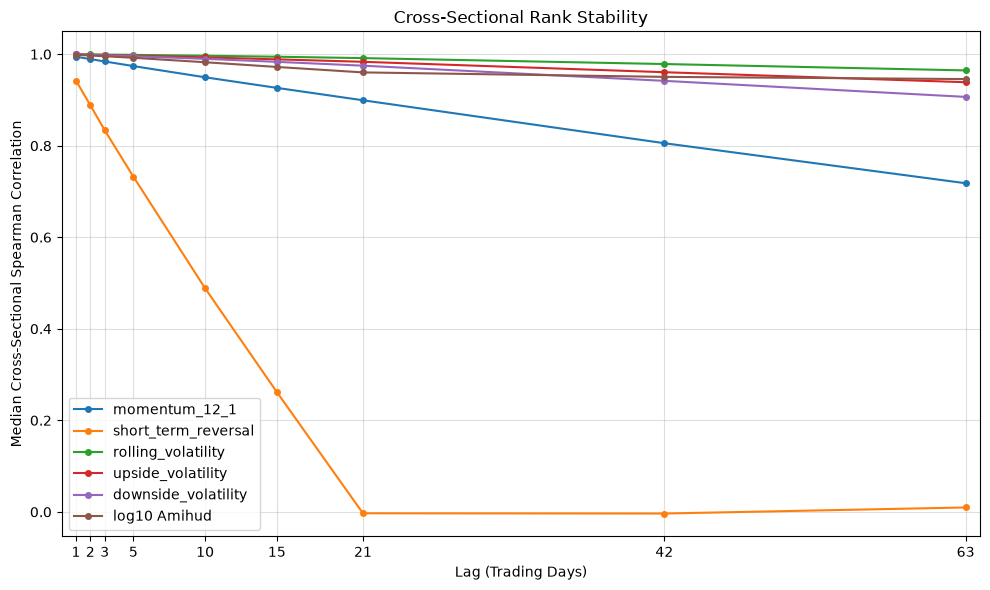

In [20]:
lags = [1, 2, 3, 5, 10, 15, 21, 42, 63]

# Dictionary to store results
stability_results = {}

fig, ax = plt.subplots(figsize=(10, 6))

for name, df in factors_clean.items():

    # Apply log10 transformation exclusively to Amihud
    if name == "amihud_illiquidity":
        vals = np.where(df.values > 0, np.log10(df.values), np.nan)
        df_proc = pd.DataFrame(vals, index=df.index, columns=df.columns)
        label = "log10 Amihud"
    else:
        df_proc = df
        label = name

    # Cross-sectional ranks (Spearman = Pearson over ranks)
    df_ranked = df_proc.rank(axis=1, method="average")

    mean_correlations = []
    median_correlations = []

    for lag in lags:

        # Shift ranked matrix
        df_lagged_ranked = df_ranked.shift(lag)

        # Row-wise Pearson correlation between ranks
        daily_corrs = df_ranked.corrwith(
            df_lagged_ranked,
            axis=1,
            method="pearson"
        )

        # Keep only days with enough valid observations
        valid_counts = df_ranked.notna() & df_lagged_ranked.notna()
        daily_corrs = daily_corrs[valid_counts.sum(axis=1) >= 10]

        mean_correlations.append(daily_corrs.mean())
        median_correlations.append(daily_corrs.median())

    # Store results
    stability_results[label] = {
        "lags": lags,
        "mean": mean_correlations,
        "median": median_correlations
    }

    # Plot median (more robust)
    ax.plot(
        lags,
        median_correlations,
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=label
    )

ax.set_xlabel("Lag (Trading Days)")
ax.set_ylabel("Median Cross-Sectional Spearman Correlation")
ax.set_title("Cross-Sectional Rank Stability")

ax.set_xticks(lags)
ax.set_xlim(min(lags)-1, max(lags)+1)

ax.grid(alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
stability_table = pd.DataFrame({
    factor: results["median"]
    for factor, results in stability_results.items()
}, index=lags)

stability_table.index.name = "Lag"

display(stability_table.map(lambda x: f"{x:.3g}"))

,momentum_12_1,short_term_reversal,rolling_volatility,upside_volatility,downside_volatility,log10 Amihud
Lag,,,,,,
1,0.995,0.942,1,1,1,0.999
2,0.989,0.888,0.999,0.999,0.999,0.997
3,0.984,0.834,0.999,0.998,0.998,0.996
5,0.974,0.732,0.998,0.997,0.995,0.992
10,0.95,0.488,0.997,0.993,0.99,0.982
15,0.926,0.262,0.994,0.989,0.983,0.972
21,0.899,-0.00312,0.991,0.983,0.975,0.96
42,0.806,-0.00361,0.978,0.961,0.942,0.95
63,0.718,0.00967,0.965,0.939,0.907,0.946


El análisis de la correlación de Spearman del ranking transversal a distintos horizontes temporales ($k = 1$ a $63$ días) revela dos dinámicas de memoria estructural completamente opuestas dentro del panel:

Por un lado, el factor Short-Term Reversal confirma su naturaleza de alta frecuencia y baja persistencia. Su correlación de ranks cae por debajo de $0.50$ ya en el día 5 ($0.488$) y colapsa de forma matemática a cero en el lag 21 ($-0.0031$), punto a partir del cual pierde totalmente la memoria temporal. Esto demuestra que la información de ordenación que proporciona este factor caduca en cuestión de días.

En el extremo opuesto, el grupo de factores inerciales muestra una estabilidad transversal extraordinaria. La Volatilidad Rolling encabeza la persistencia manteniendo una correlación superior al $0.965$ incluso a horizonte de 63 días ($1$ trimestre). Le sigue de cerca la Iliquidez de Amihud, que aunque arranca con caídas ligeras hasta el lag 21 ($0.964$), muestra una estabilización posterior que le permite alcanzar el trimestre con un $0.946$, superando en este horizonte más largo a la volatilidad upside ($0.939$) y downside ($0.907$).

Por último, el Momentum (12-1) exhibe una pauta de decaimiento suave y constante. Mantiene un elevado valor de $0.899$ al cabo de un mes (lag 21) y conserva una capacidad discriminatoria muy notable de $0.718$ al llegar al trimestre (lag 63).

### 5.3 Conclusiones

La persistencia temporal de los factores es heterogénea, por lo que una frecuencia de rebalanceo única difícilmente será óptima para todos ellos.

Los factores de carácter inercial, como Momentum, Volatilidad e Iliquidez, presentan una elevada persistencia temporal, manteniendo gran parte de su capacidad discriminativa incluso para horizontes de varias semanas. Esto sugiere que pueden implementarse mediante estrategias de baja rotación, reduciendo el impacto de los costes de transacción.

En contraste, Short-Term Reversal muestra un deterioro mucho más rápido del ranking cross-sectional. Este comportamiento implica que la información contenida en el factor se vuelve obsoleta en pocos días, por lo que su explotación requeriría rebalanceos significativamente más frecuentes. En consecuencia, la viabilidad económica de este factor dependerá de que la rentabilidad adicional obtenida compense el incremento de los costes de transacción asociados a dicha rotación.

## 6. Redundancia y Multicolinealidad (Análisis Multivariado)

### 6.1 Average cross-sectional Spearman correlation matrix

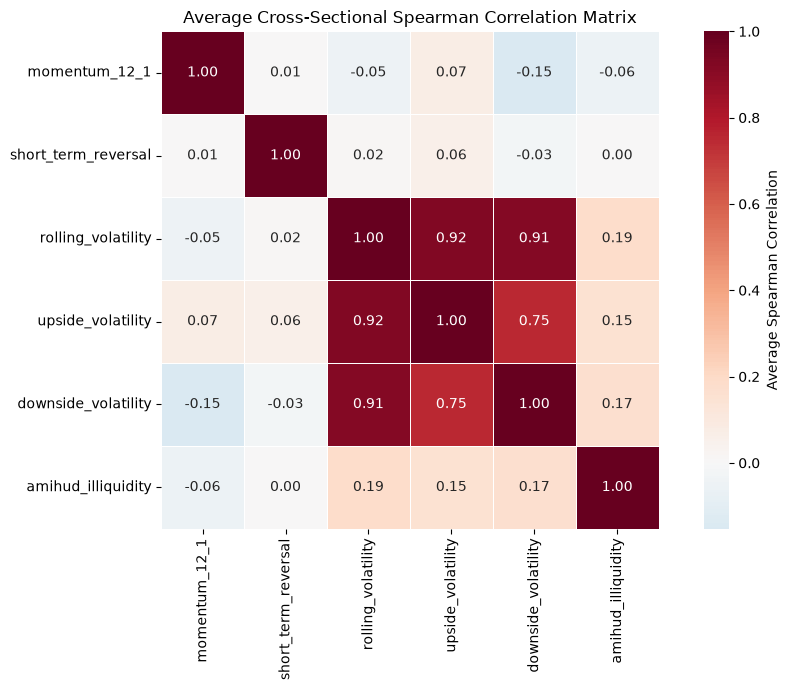

In [22]:
factor_names = list(factors_clean.keys())

processed_factors = {}

for name, df in factors_clean.items():

    # Apply log10 transformation only to Amihud
    if name == "amihud_illiquidity":
        vals = np.where(df.values > 0, np.log10(df.values), np.nan)
        processed_factors[name] = pd.DataFrame(
            vals,
            index=df.index,
            columns=df.columns
        )
    else:
        processed_factors[name] = df

# Compute one correlation matrix per day

corr_matrices = []

for date in processed_factors[factor_names[0]].index:

    # Assets × Factors matrix
    cross_section = pd.DataFrame({
        factor: processed_factors[factor].loc[date]
        for factor in factor_names
    })

    # Keep complete observations only
    cross_section = cross_section.dropna()

    if len(cross_section) < 10:
        continue

    # Daily Spearman correlation matrix
    corr = cross_section.corr(method="spearman")

    corr_matrices.append(corr)


# Average correlation matrix

mean_corr = sum(corr_matrices) / len(corr_matrices)


# Standard deviation of the correlations
corr_stack = np.stack([corr.values for corr in corr_matrices])
 
std_corr = pd.DataFrame(
    corr_stack.std(axis=0),
    index=factor_names,
    columns=factor_names
)

# Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    mean_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Average Spearman Correlation"}
)

plt.title("Average Cross-Sectional Spearman Correlation Matrix")

plt.tight_layout()
plt.show()

In [23]:
summary_rows = []

for i in range(len(factor_names)):
    for j in range(i + 1, len(factor_names)):

        # Daily correlation series for this pair of factors
        daily_corrs = np.array([
            corr.iloc[i, j]
            for corr in corr_matrices
        ])

        summary_rows.append({
            "Factor A": factor_names[i],
            "Factor B": factor_names[j],
            "Mean": daily_corrs.mean(),
            "Std": daily_corrs.std(),
            "IQR": np.percentile(daily_corrs, 75) - np.percentile(daily_corrs, 25)
        })

# Build summary table
corr_summary = (
    pd.DataFrame(summary_rows)
      .assign(**{"|Mean|": lambda x: x["Mean"].abs()})
      .sort_values("|Mean|", ascending=False)
      .drop(columns="|Mean|")
      .reset_index(drop=True)
)

# Display
display(
    corr_summary.style
        .hide(axis="index")
        .format({
            "Mean": "{:.3g}",
            "Std": "{:.3g}",
            "IQR": "{:.3g}"
        })
)

Factor A,Factor B,Mean,Std,IQR
rolling_volatility,upside_volatility,0.925,0.0245,0.0369
rolling_volatility,downside_volatility,0.915,0.0227,0.0364
upside_volatility,downside_volatility,0.749,0.0688,0.116
rolling_volatility,amihud_illiquidity,0.186,0.0725,0.105
downside_volatility,amihud_illiquidity,0.167,0.0803,0.1
momentum_12_1,downside_volatility,-0.153,0.232,0.352
upside_volatility,amihud_illiquidity,0.151,0.0743,0.101
momentum_12_1,upside_volatility,0.074,0.271,0.441
short_term_reversal,upside_volatility,0.0592,0.232,0.337
momentum_12_1,amihud_illiquidity,-0.0558,0.115,0.152


El análisis multivariado de la correlación transversal promedio demuestra que el universo de factores goza de una elevada ortogonalidad, existiendo un único foco claro de solapamiento en el bloque de las volatilidades. Al evaluar la estabilidad de estas relaciones en el tiempo mediante su desviación típica y rango intercuartílico ($\text{IQR}$), se identifican tres dinámicas clave.

En primer lugar, se observa una redundancia severa e invariable dentro del bloque de riesgos: la volatilidad total (rolling_volatility) presenta una correlación prácticamente idéntica en el tiempo tanto con la upside volatility ($0.925$; $\text{IQR} = 0.0369$) como con la downside volatility ($0.915$; $\text{IQR} = 0.0364$). Por su parte, las ramas upside y downside comparten una correlación de $0.749$, pero con una mayor dispersión temporal ($\text{IQR} = 0.116$), lo que refleja que en momentos de pánico o estrés el mercado detecta cierta asimetría en las colas de la distribución.

En segundo lugar, se confirma la ortogonalidad estructural entre las distintas familias de factores, registrando relaciones medias muy bajas ($\vert{}\rho\vert{} < 0.20$). La iliquidez (log10_amihud) apenas guarda relación con la volatilidad ($0.151$ a $0.186$) y presenta una independencia casi absoluta frente al momentum ($-0.0558$) y al reversal ($0.0010$). De igual modo, momentum_12_1 y short_term_reversal resultan completamente independientes en promedio ($0.0076$).

Por último, destaca la alta sensibilidad al régimen de mercado que exhibe el momentum frente al riesgo. Aunque sus correlaciones medias con las volatilidades son cercanas a cero ($-0.047$ con la volatilidad total), sus desviaciones típicas y rangos intercuartílicos son los más elevados de todo el panel ($\text{IQR} \approx 0.446$). Esto evidencia que la interacción entre el momentum y la volatilidad no es estática, sino que oscila drásticamente según la fase del ciclo macroeconómico.

### 6.2 Agrupamiento Jerárquico de Factores (Dendrograma)

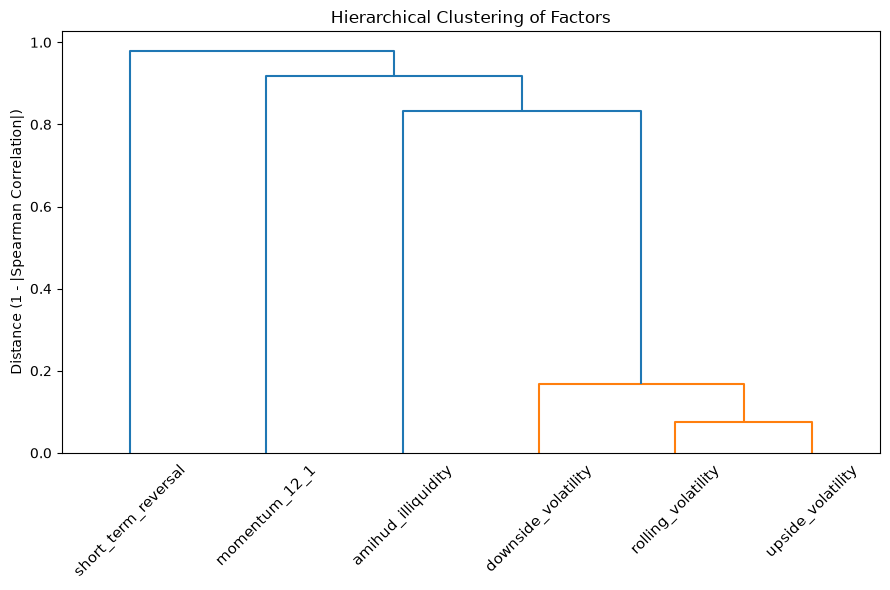

In [24]:
# Distance matrix
distance_matrix = 1 - np.abs(mean_corr)

# Condensed matrix required by scipy
condensed_dist = squareform(distance_matrix.values)

# Hierarchical clustering
Z = linkage(condensed_dist, method="average")

# Plot
plt.figure(figsize=(9,6))

dendrogram(
    Z,
    labels=mean_corr.columns,
    leaf_rotation=45,
    leaf_font_size=11
)

plt.title("Hierarchical Clustering of Factors")
plt.ylabel("Distance (1 - |Spearman Correlation|)")
plt.tight_layout()
plt.show()

El Hierarchical Clustering sobre la matriz de distancias ($1 - \vert{}\rho\vert{}$) confirma la topología del panel y sus fronteras de redundancia. La primera fusión del dendrograma une a la volatilidad total (rolling_volatility) y a la upside volatility a una distancia casi nula, sumando inmediatamente después a la downside volatility para consolidar un clúster compacto de riesgo.

A distancias mucho mayores se incorporan la iliquidez de Amihud (como dimensión intermedia) y, finalmente, el momentum y el reversal en las ramas más alejadas. En definitiva, el dendrograma reduce los seis factores a tres familias funcionales: un bloque dominante de volatilidad/riesgo (altamente redundante), una dimensión de iliquidez y dos señales de retorno completamente independientes entre sí y frente al resto.

### 6.3 Análisis de Multicolinealidad (Variance Inflation Factor - VIF)

In [25]:
vif_results = []

for date in processed_factors[factor_names[0]].index:

    # Assets × Factors matrix
    cross_section = pd.DataFrame({
        factor: processed_factors[factor].loc[date]
        for factor in factor_names
    }).dropna()

    # Skip dates with too few observations
    if len(cross_section) < 10:
        continue

    X = cross_section.values

    vifs = [
        variance_inflation_factor(X, i)
        for i in range(X.shape[1])
    ]

    vif_results.append(vifs)

# Summary statistics
vif_df = pd.DataFrame(
    vif_results,
    columns=factor_names
)

vif_summary = pd.DataFrame({
    "Mean VIF": vif_df.mean(),
    "Median VIF": vif_df.median(),
    "IQR": vif_df.quantile(0.75) - vif_df.quantile(0.25)
})

display(
    vif_summary.style.format("{:.3g}")
)

,Mean VIF,Median VIF,IQR
momentum_12_1,2.12,1.99,0.988
short_term_reversal,1.68,1.39,0.571
rolling_volatility,379,351,82.3
upside_volatility,116,102,36.9
downside_volatility,91.8,84.1,29.6
amihud_illiquidity,11.3,10.9,2.91


El diagnóstico cuantitativo mediante el Factor de Inflación de la Varianza (VIF) confirma de forma incontestable la presencia de una multicolinealidad severa en el bloque de las volatilidades. Mientras que variables como el momentum ($\text{VIF media} = 2.12$; $\text{mediana} = 1.99$) y el short-term reversal ($\text{VIF media} = 1.68$; $\text{mediana} = 1.39$) presentan valores holgadamente por debajo del umbral crítico de $5$, el grupo de riesgo pulveriza cualquier límite de aceptabilidad estadística.

En concreto, la volatilidad total (rolling_volatility) registra un VIF medio desorbitado de $379$ (con una mediana de $351$), acompañada por la upside volatility ($\text{VIF media} = 116$) y la downside volatility ($\text{VIF media} = 91.8$). Asimismo, la iliquidez de Amihud supera ligeramente la frontera de alerta con un VIF medio de $11.3$ (mediana $10.9$), arrastrada por su ligera correlación con el bloque de riesgo.

Estos resultados demuestran que incluir las tres medidas de volatilidad simultáneamente en un modelo lineal introduciría una inestabilidad matemática extrema en la estimación de los parámetros (alpha). Por tanto, se concluye la necesidad imperativa de eliminar o filtrar la redundancia dentro de la familia de volatilidades antes de proceder a la fase de combinación o modelado multivariado.

### 6.4 Conclusiones de Redundancia y Selección Preliminar

El análisis multivariado de correlación cross-sectional, el agrupamiento jerárquico y el diagnóstico VIF confirman la existencia de una multicolinealidad crítica en el bloque de riesgo, donde la volatilidad total, la upside volatility y la downside volatility forman un clúster sumamente redundante que inestabilizaría de forma severa los parámetros de cualquier modelo lineal. Por el contrario, la iliquidez de Amihud, el momentum a doce meses y el short-term reversal han demostrado una ortogonalidad estructural limpia, aportando dimensiones de información completamente independientes entre sí y respecto al riesgo.

Esta estructura obliga a filtrar la familia de volatilidades para eliminar la inflación de varianza antes de pasar al modelado. Dado que el análisis de redundancia no determina por sí solo cuál de las tres medidas de riesgo debe conservarse, la selección definitiva se trasladará al estudio de poder predictivo preliminar mediante el Information Coefficient, cuya capacidad explicativa sobre los retornos futuros a un mes servirá como criterio de corte final.

## 7. Preliminary Predictive Power

Una vez evaluada la persistencia temporal y eliminada la redundancia entre factores, es necesario determinar la validez empírica de las señales. El análisis de Information Coefficient (IC) actúa como el filtro cuantitativo definitivo antes de la fase de modelado, evaluando la capacidad real de cada factor para anticipar la ordenación del ranking de rendimientos transversales a un horizonte de 21 días ($\text{Return}_{t+21}$).

Para medir esta relación, se calcula diariamente la correlación de rangos de Spearman entre el valor del factor en $t$ y el retorno futuro acumulado. Este enfoque no paramétrico permite capturar relaciones monótonas sin asumir linealidad ni ser sensible a valores atípicos. De la serie temporal de ICs resultante se extraen dos métricas fundamentales: la media del IC (potencia y dirección de la señal) y el ICIR (Information Coefficient Information Ratio, definido como el cociente entre la media del IC y su desviación típica), que mide la estabilidad y consistencia temporal del factor.

Este análisis cumple un doble objetivo fundamental: validar que las señales conservan capacidad explicativa antes de su combinación y resolver el dilema de redundancia detectado en el bloque de riesgo, utilizando el ICIR como criterio de corte objetivo para seleccionar la medida de volatilidad con mejor relación entre poder predictivo y estabilidad.

### 7.1 Evaluación de Poder Predictivo, Consistencia y Significatividad Estadística

In [26]:
from src.analysis.factor_diagnostics import compute_forward_returns

ic_results = {}

adj_close = prices_clean["Adj Close"]
forward_return_21 = compute_forward_returns(adj_close, horizon=21)

# pre-calulate the ranks of forward returns for efficiency
return_ranks = forward_return_21.rank(axis=1, pct=True)

for name, df in factors_clean.items():

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        vals = np.where(df.values > 0, np.log10(df.values), np.nan)
        factor = pd.DataFrame(vals, index=df.index, columns=df.columns)
        label = "log10 Amihud Illiquidity"
    else:
        factor = df
        label = name

    factor_ranks = factor.rank(axis=1, pct=True)

    # 2. Pearson correlation over ranks (Spearman correlation)
    daily_ic = factor_ranks.corrwith(return_ranks, axis=1, method="pearson")

    # 3. Mask for valid counts: only keep days with at least 10 valid observations
    valid_counts = factor.notna() & forward_return_21.notna()
    daily_ic = daily_ic[valid_counts.sum(axis=1) >= 10]

    ic_results[label] = daily_ic

In [27]:
summary_rows = []

for factor, ic_series in ic_results.items():

    ic_series = ic_series.dropna()

    n = len(ic_series)

    mean_ic = ic_series.mean()
    median_ic = ic_series.median()
    std_ic = ic_series.std()
    icir = mean_ic / std_ic

    # Hit Rate
    hit_rate = (ic_series > 0).mean() * 100

    # One-sample t-test: H0 -> Mean(IC)=0
    t_stat, p_value = ttest_1samp(ic_series, popmean=0)

    summary_rows.append({

        "Factor": factor,
        "Mean IC": mean_ic,
        "Median IC": median_ic,
        "Std IC": std_ic,
        "ICIR": icir,
        "% IC > 0": hit_rate,
        "t-stat": t_stat,
        "p-value": p_value

    })

ic_summary = (
    pd.DataFrame(summary_rows)
      .sort_values("ICIR", ascending=False)
      .reset_index(drop=True)
)

display(
    ic_summary.style
        .hide(axis="index")
        .format({
            "Mean IC": "{:.3g}",
            "Median IC": "{:.3g}",
            "Std IC": "{:.3g}",
            "ICIR": "{:.3g}",
            "% IC > 0": "{:.1f}",
            "t-stat": "{:.2f}",
            "p-value": "{:.3g}"
        })
)

Factor,Mean IC,Median IC,Std IC,ICIR,% IC > 0,t-stat,p-value
log10 Amihud Illiquidity,0.0327,0.0341,0.107,0.307,61.7,18.16,1.64e-70
upside_volatility,0.0291,0.0376,0.227,0.128,55.6,7.57,4.91e-14
rolling_volatility,0.0291,0.0325,0.245,0.119,54.3,7.01,2.76e-12
downside_volatility,0.0254,0.0221,0.223,0.114,54.3,6.76,1.65e-11
momentum_12_1,0.0103,0.0263,0.196,0.0528,55.5,3.13,0.00178
short_term_reversal,-0.0154,-0.00312,0.159,-0.0969,49.1,-5.73,1.06e-08


El análisis conjunto del Information Coefficient (IC), la tasa de aciertos y los test de significatividad ofrece un diagnóstico claro sobre la validez empírica de cada señal a un horizonte de 21 días, permitiendo establecer un filtro objetivo antes de abordar el modelado.

En primer lugar, la iliquidez de Amihud se consolida como el factor más sólido y constante de todo el panel. Registra el mayor Mean IC ($0.0327$), la menor volatilidad en la señal ($\text{Std IC} = 0.1070$) y un ICIR sobresaliente ($0.3070$). Su tasa de aciertos del $61.7\%$ junto a un estadístico $t$ de $18.16$ confirman la presencia de una prima de iliquidez altamente estable y estadísticamente incontestable a horizonte mensual.

Por su parte, aunque las tres métricas de la familia de volatilidades muestran una significatividad estadística robusta ($t > 6.7$), la upside volatility supera a la volatilidad total y a la downside volatility en todos los frentes. Esta señal alcanza la mayor tasa de acierto ($55.6\%$), el mejor ICIR ($0.1280$) y el estadístico $t$ más elevado ($7.57$). Dado el VIF extremo observado anteriormente en este bloque, estos resultados justifican seleccionar la upside volatility como la única representante de riesgo para el modelo, resolviendo de golpe la multicolinealidad.

Finalmente, los factores basados en el comportamiento del retorno muestran dinámicas contrapuestas. El momentum a doce meses conserva significatividad estadística ($t = 3.13$, $p = 0.0018$) con un $55.5\%$ de aciertos, aunque su modesto ICIR ($0.0528$) evidencia que su señal pierde fuerza de forma aislada a un mes y requiere combinación multivariada. En sentido opuesto, el short-term reversal presenta un estadístico $t$ marcadamente negativo ($-5.73$) y un acierto por debajo del azar ($49.1\%$), demostrando estadísticamente que el efecto rebote de corto plazo se disipa o invierte a horizonte de 21 días, por lo que su inclusión solo añadiría ruido.

### 7.2. Evolución Temporal del IC Acumulado y Análisis de Régimen

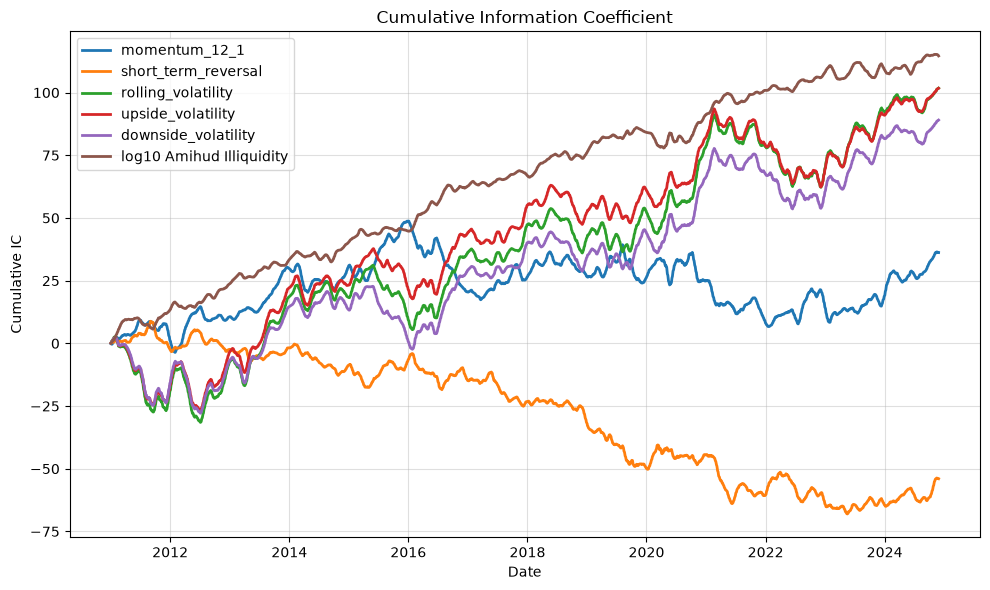

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

for factor, ic_series in ic_results.items():

    ax.plot(
        ic_series.index,
        ic_series.cumsum(),
        linewidth=2,
        label=factor
    )

ax.set_title("Cumulative Information Coefficient")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative IC")

ax.grid(alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

La gráfica del Information Coefficient acumulado ($\sum \text{IC}_t$) corrobora visualmente las métricas cuantitativas y permite diagnosticar la estabilidad de las señales a lo largo de los diferentes regímenes de mercado.

El comportamiento de la iliquidez (log10_amihud) resulta excepcional: muestra una trayectoria ascendente continua y con la pendiente más pronunciada de todo el panel. Su estabilidad casi lineal a lo largo de los años confirma que la prima de iliquidez no depende de fases concretas del ciclo, operando como el generador de alfa más consistente.

Por su parte, las tres métricas de volatilidad exhiben una dinámica dividida en dos fases. Tras un periodo inicial ligeramente bajista, alrededor del año 2013 inician una senda de crecimiento constante pero con mayor volatilidad interna y una pendiente inferior a la de la iliquidez. En este bloque, la downside volatility se mantiene sistemáticamente por debajo de las otras dos, reforzando la elección de la upside volatility como la señal de riesgo dominante.

En cuanto a los factores de retorno, sus trayectorias justifican su tratamiento en el modelado. El momentum a doce meses experimenta un fuerte crecimiento inicial hasta 2016, punto en el que entra en una fase lateralizada con oscilaciones cíclicas que no logran batir su máximo previo. Aunque su saldo global se mantiene en terreno positivo por encima del reversal, este estancamiento evidencia la necesidad de combinarlo con señales de riesgo o filtros de régimen. Por el contrario, el short-term reversal muestra una pendiente negativa constante desde el primer momento, confirmando visualmente la destrucción paulatina de la señal a horizonte de 21 días.

## 8. Preprocessing Decisions

Como resultado de las evaluaciones de consistencia de datos, autocorrelación, multicolinealidad y poder predictivo preliminar, se formalizan las decisiones estructurales que configuran la entrada para la fase de modelado.

### 8.1. Definición del universo

* **Eliminar SW y AMCR**: Históricos inconsistentes asociados a eventos corporativos (fusiones y reconstrucción sintética de datos).
* **Fijar el inicio tras las primeras 252 sesiones**: Garantiza que todos los factores con ventana móvil estén plenamente definidos y elimina el periodo de warm-up.

### 8.2. Selección de factores

El diagnóstico conjunto de redundancia, persistencia temporal e Information Coefficient permite definir el conjunto final de factores que continuará en la fase de modelado:

* **Log10(Amihud)** [Mantener]: Constituye el factor con mayor capacidad predictiva y estabilidad temporal del panel. Presenta el mayor Mean IC, el ICIR más alto y una tasa de acierto superior al 61%, con una significatividad estadística muy elevada.
* **Upside Volatility** [Mantener]: Dentro del bloque de riesgo, presenta el mejor desempeño predictivo y la mayor estabilidad temporal, resolviendo la elevada multicolinealidad detectada al convertirse en la única medida de volatilidad seleccionada.
* **12-1 Momentum** [Mantener]: Aunque su capacidad predictiva individual es más moderada que la de la iliquidez, conserva significatividad estadística y aporta una fuente de información de tendencia complementaria y totalmente ortogonal.
* **Short-Term Reversal** [Eliminar]: Su Mean IC negativo, su tasa de acierto inferior al 50% y la pérdida de señal al horizonte de 21 días indican que este factor añade más ruido que información explicativa al modelo.

En consecuencia, el conjunto final de factores queda integrado por Log10(Amihud), Upside Volatility y 12-1 Momentum, proporcionando una combinación equilibrada de señales de liquidez, riesgo y tendencia, con baja redundancia y sólida evidencia empírica.

### 8.3. Pipeline de procesamiento

Todas las señales seleccionadas se someterán a un tratamiento de acondicionamiento antes de la combinación multivariada para corregir asimetrías, mitigar el impacto de outliers y garantizar la comparabilidad transversal:

* **Amihud Illiquidity**: Transformación logarítmica (log10) + Winsorize + Cross-sectional Z-score
* **Upside Volatility**: Winsorize + Cross-sectional Z-score
* **12-1 Momentum**: Winsorize + Cross-sectional Z-score